In [714]:
# Mobility Heatmap Analysis Notebook
import pandas as pd
import numpy as np
import geopandas as gpd
import pickle as pkl
from shapely.geometry import Point, box
from geolib import geohash as geolib
import h3
import shapely.geometry as geometry
import os

# -------------------------------------------------------
# Load Data
# -------------------------------------------------------

paths = pd.read_csv("data/all_paths_128.csv", sep=";")
movements = pd.read_csv("data/all_movements_138.csv", sep=";", parse_dates=["start_time", "end_time"])
steps = pd.read_csv("data/all_steps_2.csv")

# COnvert dates to swiss timezone
movements["start_time"] = movements["start_time"].dt.tz_convert("Europe/Zurich")
movements["end_time"] = movements["end_time"].dt.tz_convert("Europe/Zurich")

display(movements.head())

# -------------------------------------------------------
# Load / init cache
# -------------------------------------------------------
try:
    geohashes_cache = pkl.load(open("./geohashes_to_coords.pkl", "rb"))
except FileNotFoundError:
    geohashes_cache = {}

# Read geohashes to coordinates mapping (dataframe with columns: geohash, latitude, longitude)
geo_to_coords = pd.read_pickle('geohashes_to_coords.pkl')

# Function to complete geo_to_coords with missing geohashes
def complete_geo_to_coords(geo_to_coords, geohashes):
    missing_geohashes = set(geohashes) - set(geo_to_coords['geohash'])
    new_rows = []
    for gh in missing_geohashes:
        try:
            lat, lon = geolib.decode(gh)
            new_rows.append({'geohash': gh, 'latitude': lat, 'longitude': lon})
        except Exception as e:
            print(f"Error decoding geohash {gh}: {e}")
    if new_rows:
        geo_to_coords = pd.concat([geo_to_coords, pd.DataFrame(new_rows)], ignore_index=True)
        geo_to_coords.to_pickle('geohashes_to_coords.pkl') # Save to file
    return geo_to_coords

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving
0,1199121CX,2024-09-03 13:28:03+02:00,2024-09-03 13:30:07+02:00,u0m44x,u0m44x,518,ON_BICYCLE,ON_BICYCLE,2,False
1,1199121CX,2024-09-03 17:12:18+02:00,2024-09-03 17:17:23+02:00,u0m44x,u0m44x,359,WALKING,WALKING,0,False
2,1199121CX,2024-09-03 17:52:14+02:00,2024-09-03 17:59:24+02:00,u0m44x,u0m468,416,WALKING,WALKING,0,False
3,1199121CX,2024-09-03 17:59:25+02:00,2024-09-03 18:21:34+02:00,u0m468,u0m464,3091,ELECTRIC_BUS,ELECTRIC_BUS,197,False
4,4L5S1E,2024-09-03 18:23:18+02:00,2024-09-03 18:25:21+02:00,u0m709,u0m70d,570,ON_BICYCLE,ON_BICYCLE,3,False


In [715]:
# Remove trips that overlap between each other in time for the same participant_id, which means that the same participant used several phones at the same time...
movements["duration"] = movements["end_time"] - movements["start_time"]

def remove_overlaps(group):
    participant = group.name
    group = group.sort_values("start_time").copy()

    kept = []
    cluster = []
    cluster_end = None

    for _, row in group.iterrows():
        row = row.copy()
        row["participant_id"] = participant

        if not cluster:
            cluster = [row]
            cluster_end = row["end_time"]
            continue

        if row["start_time"] < cluster_end:
            cluster.append(row)
            cluster_end = max(cluster_end, row["end_time"])
        else:
            best = max(cluster, key=lambda r: r["duration"])
            kept.append(best)
            cluster = [row]
            cluster_end = row["end_time"]

    if cluster:
        best = max(cluster, key=lambda r: r["duration"])
        kept.append(best)

    return pd.DataFrame(kept)

movements = (
    movements.groupby("participant_id", group_keys=False)
      .apply(remove_overlaps)
      .reset_index(drop=True)
)

print(f"After removing overlaps, shape: {movements.shape}")

After removing overlaps, shape: (40724, 11)


/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_54470/4263850989.py:38: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [723]:
# Load temperature cache
DATA_DIR_INTERNAL = "./data"
os.makedirs(DATA_DIR_INTERNAL, exist_ok=True)
temp_cache_path = os.path.join(DATA_DIR_INTERNAL, "temperature_cache.pkl")

try:
    temperature_cache = pkl.load(open(temp_cache_path, "rb"))
except (FileNotFoundError, EOFError):
    temperature_cache = {}

In [724]:
import rasterio

def polygon_vertex_centroid_points(poly):
    """
    Returns list of (x,y) = (lon,lat) points: polygon exterior vertices + centroid.
    """
    coords = list(poly.exterior.coords)[:-1]  # drop closing duplicate
    c = poly.centroid
    coords.append((c.x, c.y))                 # (lon,lat)
    return coords

def add_elevation_to_gdf(gdf, dem_path):
    """
    Adds average elevation to each polygon in gdf by sampling DEM at polygon vertices + centroid.
    Returns new GeoDataFrame with 'avg_elevation' column.
    """
    all_points = []
    row_slices = []  # (start, end) indices into all_points

    # Open DEM first so we can safely reproject if needed
    with rasterio.open(dem_path) as src:
        # Reproject geometries to DEM CRS if needed
        gdf_src = gdf.to_crs(src.crs) if (gdf.crs != src.crs) else gdf

        for poly in gdf_src.geometry:
            pts = polygon_vertex_centroid_points(poly)  # always (lon,lat) in EPSG:4326; (x,y) in general CRS
            start = len(all_points)
            all_points.extend(pts)
            row_slices.append((start, len(all_points)))

        # Sample raster at all points
        elev = np.array([v[0] for v in src.sample(all_points)], dtype="float64")

        # Handle nodata if present
        if src.nodata is not None:
            elev[elev == src.nodata] = np.nan
        else:
            # SwissDEM behavior in your file: 0 means "outside coverage"
            elev[elev == 0] = np.nan

    # Mean elevation per row (ignore NaNs)
    means = [np.nanmean(elev[s:e]) for (s, e) in row_slices]

    out = gdf.copy()
    out["avg_elevation"] = means

    # Keep only rows with valid elevation
    out = out[~np.isnan(out["avg_elevation"])]

    return out

# Add elevation using a single coordinate
def get_elevation_at_point(lon, lat, dem):
    coords = [(lon, lat)]
    for val in dem.sample(coords):
        elevation = val[0]
        if elevation == dem.nodata:
            return np.nan
        return elevation
    return np.nan

In [725]:
# Geohashes in switzerland
swiss_geohashes = [f"u0{c}" for c in "kmqrhjnp"]
# Keep only bern
#swiss_geohashes = ["u0m"]
# Keep only zurich-winterthur
#swiss_geohashes = ["u0q"]

# Translate selected modes of transport to corresponding actual transport modes
def translate_mot(mot):
    if mot == "CAR" or mot == "ELECTRIC_CAR" or mot == "HYBRID_CAR" or mot == "MOTORBIKE":
        return "Car"
    elif mot == "TRAIN":
        return "Train"
    elif mot == "WALKING":
        return "Walking"
    elif mot == "ON_BICYCLE" or mot == "ELECTRIC_BIKE" or mot == "SCOOTER" or mot == "ELECTRIC_SCOOTER":
        return "Bicycle"
    elif mot == "BUS" or mot == "ELECTRIC_BUS" or mot == "COACH":
        return "Bus"
    elif mot == "TRAM":
        return "Tram"
    elif mot == "PLANE":
        return "Plane"
    elif mot == "BOAT" or mot == "BOAT_NO_ENGINE":
        return "Boat"
    else:
        return mot

In [726]:
# Get canton boundaries
# Load cantonal boundaries
gpkg = "data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"

# selected layer: cantonal boundaries
lyr = "tlm_kantonsgebiet"

canton_gdf = gpd.read_file(gpkg, layer=lyr)

In [727]:
# Keep only max 7 characters of geohash for paths
paths['geohash'] = paths['geohash'].str.slice(0, 8)

In [728]:
# Keep only data in switzerland
paths = paths[(paths['geohash'].str.startswith(tuple(swiss_geohashes)))]

movements = movements[(movements['start_geohash'].str.startswith(tuple(swiss_geohashes)))]
movements = movements[movements['end_geohash'].str.startswith(tuple(swiss_geohashes))]

# Translate mean of transport by simplifying (e.g., CAR, ELECTRIC_CAR, HYBRID_CAR -> CAR)
paths['mean_of_transport'] = paths['mode_of_transport'].apply(translate_mot)

movements['mean_of_transport'] = movements['mean_of_transport'].apply(translate_mot)
movements['original_mean_of_transport'] = movements['original_mean_of_transport'].apply(translate_mot)

In [729]:
combined_geohashes = set(movements['start_geohash']).union(set(movements['end_geohash'])).union(set(paths['geohash'].dropna()))
geo_to_coords = complete_geo_to_coords(geo_to_coords, combined_geohashes)

In [730]:
## Convert distance to int
movements['distance(m)'] = movements['distance(m)'].astype(int)

## Convert gCO2 to int
movements['gCO2'] = movements['gCO2'].astype(int)

In [731]:
# Convert start_time and end_time to datetime
movements["start_time"] = pd.to_datetime(movements["start_time"], errors="coerce")
movements["end_time"] = pd.to_datetime(movements["end_time"], errors="coerce")

movements["dow"] = movements["start_time"].dt.day_of_week
movements["is_weekend"] = movements["dow"].isin([5,6])

movements["date"] = movements["start_time"].dt.date

In [732]:
# See the temperature cache structure
temperature_cache

{'u0qnnq2025-05-19': {'latitude': 47.486816,
  'longitude': 8.719212,
  'generationtime_ms': 0.18584728240966797,
  'utc_offset_seconds': 0,
  'timezone': 'GMT',
  'timezone_abbreviation': 'GMT',
  'elevation': 448.0,
  'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C'},
  'hourly': {'time': ['2025-05-19T00:00',
    '2025-05-19T01:00',
    '2025-05-19T02:00',
    '2025-05-19T03:00',
    '2025-05-19T04:00',
    '2025-05-19T05:00',
    '2025-05-19T06:00',
    '2025-05-19T07:00',
    '2025-05-19T08:00',
    '2025-05-19T09:00',
    '2025-05-19T10:00',
    '2025-05-19T11:00',
    '2025-05-19T12:00',
    '2025-05-19T13:00',
    '2025-05-19T14:00',
    '2025-05-19T15:00',
    '2025-05-19T16:00',
    '2025-05-19T17:00',
    '2025-05-19T18:00',
    '2025-05-19T19:00',
    '2025-05-19T20:00',
    '2025-05-19T21:00',
    '2025-05-19T22:00',
    '2025-05-19T23:00'],
   'temperature_2m': [11.0,
    10.5,
    9.8,
    9.2,
    8.8,
    9.5,
    12.0,
    14.1,
    16.4,
    18.6,
    20.2,


In [733]:
movements.head()

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,duration,dow,is_weekend,date
0,0H2T3S,2025-01-28 17:07:52+01:00,2025-01-28 17:53:06+01:00,u0mgth,u0qjd2,49134,Train,Train,343,False,0 days 00:45:14,1,False,2025-01-28
1,0H2T3S,2025-01-28 17:57:29+01:00,2025-01-28 18:01:17+01:00,u0qjd2,u0qj6w,1581,Walking,Walking,0,False,0 days 00:03:48,1,False,2025-01-28
2,0H2T3S,2025-01-28 18:03:28+01:00,2025-01-28 18:34:50+01:00,u0qj6w,u0qj5x,8568,Bus,Bus,1130,False,0 days 00:31:22,1,False,2025-01-28
3,0H2T3S,2025-01-28 18:34:51+01:00,2025-01-28 18:48:06+01:00,u0qj5x,u0qj78,471,Walking,Walking,0,False,0 days 00:13:15,1,False,2025-01-28
4,0L3S1J,2025-05-23 11:54:16+02:00,2025-05-23 12:02:25+02:00,u0qnnq,u0qnnr,681,Walking,Walking,0,False,0 days 00:08:09,4,False,2025-05-23


In [734]:
# Add temperature data to the movements
# Example of temperature cache:
'''
{'u0qnnq2025-05-19': {'latitude': 47.486816,
  'longitude': 8.719212,
  'generationtime_ms': 0.18584728240966797,
  'utc_offset_seconds': 0,
  'timezone': 'GMT',
  'timezone_abbreviation': 'GMT',
  'elevation': 448.0,
  'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C'},
  'hourly': {'time': ['2025-05-19T00:00',
    '2025-05-19T01:00',
    '2025-05-19T02:00',
    '2025-05-19T03:00',
    '2025-05-19T04:00',
    '2025-05-19T05:00',
    '2025-05-19T06:00',
    '2025-05-19T07:00',
    '2025-05-19T08:00',
    '2025-05-19T09:00',
    '2025-05-19T10:00',
    '2025-05-19T11:00',
    '2025-05-19T12:00',
    '2025-05-19T13:00',
    '2025-05-19T14:00',
    '2025-05-19T15:00',
    '2025-05-19T16:00',
...
    22.8,
    21.6,
    20.5,
    19.6]}},
    '''
def get_temperature_for_movement(row, temperature_cache):
    tme = row['start_time']
    date_str = tme.strftime("%Y-%m-%d")
    time_str = tme.strftime("%Y-%m-%dT%H:00")
    geohash = row['start_geohash'][:6]
    
    cache_key = f"{geohash}{date_str}"

    if cache_key in temperature_cache:
        entry = temperature_cache[cache_key]
        if 'hourly' in entry and 'time' in entry['hourly'] and 'temperature_2m' in entry['hourly']:
            try:
                idx = entry['hourly']['time'].index(time_str)
                return entry['hourly']['temperature_2m'][idx]
            except (ValueError, IndexError):
                pass
    return np.nan

movements['temperature'] = movements.apply(lambda row: get_temperature_for_movement(row, temperature_cache), axis=1)

In [735]:
movements.head()

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,duration,dow,is_weekend,date,temperature
0,0H2T3S,2025-01-28 17:07:52+01:00,2025-01-28 17:53:06+01:00,u0mgth,u0qjd2,49134,Train,Train,343,False,0 days 00:45:14,1,False,2025-01-28,3.9
1,0H2T3S,2025-01-28 17:57:29+01:00,2025-01-28 18:01:17+01:00,u0qjd2,u0qj6w,1581,Walking,Walking,0,False,0 days 00:03:48,1,False,2025-01-28,4.3
2,0H2T3S,2025-01-28 18:03:28+01:00,2025-01-28 18:34:50+01:00,u0qj6w,u0qj5x,8568,Bus,Bus,1130,False,0 days 00:31:22,1,False,2025-01-28,3.0
3,0H2T3S,2025-01-28 18:34:51+01:00,2025-01-28 18:48:06+01:00,u0qj5x,u0qj78,471,Walking,Walking,0,False,0 days 00:13:15,1,False,2025-01-28,2.2
4,0L3S1J,2025-05-23 11:54:16+02:00,2025-05-23 12:02:25+02:00,u0qnnq,u0qnnr,681,Walking,Walking,0,False,0 days 00:08:09,4,False,2025-05-23,12.4


In [736]:
movements

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,duration,dow,is_weekend,date,temperature
0,0H2T3S,2025-01-28 17:07:52+01:00,2025-01-28 17:53:06+01:00,u0mgth,u0qjd2,49134,Train,Train,343,False,0 days 00:45:14,1,False,2025-01-28,3.9
1,0H2T3S,2025-01-28 17:57:29+01:00,2025-01-28 18:01:17+01:00,u0qjd2,u0qj6w,1581,Walking,Walking,0,False,0 days 00:03:48,1,False,2025-01-28,4.3
2,0H2T3S,2025-01-28 18:03:28+01:00,2025-01-28 18:34:50+01:00,u0qj6w,u0qj5x,8568,Bus,Bus,1130,False,0 days 00:31:22,1,False,2025-01-28,3.0
3,0H2T3S,2025-01-28 18:34:51+01:00,2025-01-28 18:48:06+01:00,u0qj5x,u0qj78,471,Walking,Walking,0,False,0 days 00:13:15,1,False,2025-01-28,2.2
4,0L3S1J,2025-05-23 11:54:16+02:00,2025-05-23 12:02:25+02:00,u0qnnq,u0qnnr,681,Walking,Walking,0,False,0 days 00:08:09,4,False,2025-05-23,12.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40719,9W8SXR,2025-11-18 12:24:04+01:00,2025-11-18 12:46:20+01:00,u0qhdy,u0qjy5,28751,Train,Train,201,True,0 days 00:22:16,1,False,2025-11-18,NaN
40720,9W8SXR,2025-11-18 18:31:16+01:00,2025-11-18 18:38:29+01:00,u0qnnq,u0qnnm,515,Walking,Walking,0,True,0 days 00:07:13,1,False,2025-11-18,NaN
40721,9W8SXR,2025-11-19 07:39:17+01:00,2025-11-19 08:24:00+01:00,u0qnnr,u0qtv0,54162,Train,Train,379,True,0 days 00:44:43,2,False,2025-11-19,NaN
40722,9W8SXR,2025-11-19 17:57:19+01:00,2025-11-19 18:35:37+01:00,u0qtv1,u0qnnq,54108,Train,Train,378,True,0 days 00:38:18,2,False,2025-11-19,NaN


## Analyze movements with active modes vs temperature

### 1. Build the participant-day table

In [737]:
### Compute max temperature of the day at all locations along a movement and assign it to the movement instead of the average temperature
def get_daily_max_temp_geohash(geohash, date, gh_prec=6):
    gh = geohash[:gh_prec]
    cache_key = f"{gh}{date}"
    if cache_key in temperature_cache:
        entry = temperature_cache[cache_key]
        if 'hourly' in entry and 'temperature_2m' in entry['hourly']:
            return max(entry['hourly']['temperature_2m'])
    return np.nan

def build_person_day_max_temp_from_cache(movements, gh_prec=6):
    start_locs = (
        movements[["participant_id", "date", "start_geohash"]]
        .rename(columns={
            "start_geohash": "geohash"
        })
    )

    end_locs = (
        movements[["participant_id", "date", "end_geohash"]]
        .rename(columns={
            "end_geohash": "geohash"
        })
    )

    visited = pd.concat([start_locs, end_locs], ignore_index=True).drop_duplicates()
    visited = visited.dropna(subset=["participant_id", "date", "geohash"]).copy()

    visited["location_day_max_temp"] = visited.apply(
        lambda r: get_daily_max_temp_geohash(
            r["geohash"], r["date"], gh_prec=gh_prec
        ),
        axis=1
    )

    person_day_max = (
        visited.groupby(["participant_id", "date"], as_index=False)["location_day_max_temp"]
        .max()
        .rename(columns={"location_day_max_temp": "max_temp"})
    )

    return person_day_max

Threshold choice

In [739]:
import numpy as np
import pandas as pd

ACTIVE_WALK = "Walking"
ACTIVE_BIKE = "Bicycle"

df = movements.copy()
#df = df.loc[df["is_weekend"]].copy()

df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce")
df["duration"] = (df["end_time"] - df["start_time"]).dt.total_seconds()

df = df[df["duration"].notna() & (df["duration"] > 0)].copy()

person_day_max = build_person_day_max_temp_from_cache(df, gh_prec=6)
df = df.merge(person_day_max, on=["participant_id", "date"], how="left")
df = df.dropna(subset=["max_temp"])

# Keep only data in warm months (June to September)
df["month"] = df["start_time"].dt.month
df = df[df["month"].isin([6, 7, 8, 9])].copy()

print(f"Proportion of trips with distance <= 1000m: {(df['distance(m)'] <= 1000).mean()}")
print(f"Proportion of trips with distance <= 2000m: {(df['distance(m)'] <= 2000).mean()}")

walk = df[df["mean_of_transport"] == "Walking"]["distance(m)"]

print(walk.quantile([0.5, 0.75, 0.9, 0.95]))

# Keep only short trips, to see mode substitution effects (e.g., taking a mode of transport instead of walking or biking for short trips when it's hot).
df = df[df["distance(m)"] <= 1500].copy()

df["walk_duration"] = np.where(df["mean_of_transport"] == ACTIVE_WALK, df["duration"], 0)
df["bike_duration"] = np.where(df["mean_of_transport"] == ACTIVE_BIKE, df["duration"], 0)

daily = (
    df.groupby(["participant_id", "date"], as_index=False)
      .agg(
          max_temp=("max_temp", "first"),
          total_duration=("duration", "sum"),
          walk_duration=("walk_duration", "sum"),
          bike_duration=("bike_duration", "sum"),
          total_trips=("mean_of_transport", "count"),
          total_distance=("distance(m)", "sum")
      )
)

#daily = daily[(daily["total_trips"] >= 3) & (daily["total_duration"] > 0)].copy()

daily["walk_ratio"] = daily["walk_duration"] / daily["total_duration"]
daily["bike_ratio"] = daily["bike_duration"] / daily["total_duration"]
daily["active_ratio"] = (daily["walk_duration"] + daily["bike_duration"]) / daily["total_duration"]


Proportion of trips with distance <= 1000m: 0.44703851744186046
Proportion of trips with distance <= 2000m: 0.6192768895348837
0.50     538.0
0.75     879.0
0.90    1481.1
0.95    2129.5
Name: distance(m), dtype: float64


### 2. Fit the models

Use a simple linear temperature effect model. Minimal version, but more than enough.

In [740]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

results = {}

for ratio in ["walk_ratio", "bike_ratio", "active_ratio"]:
    model = smf.glm(
        f"{ratio} ~ max_temp",
        data=daily,
        family=sm.families.Binomial()
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": daily["participant_id"]}
    )
    results[ratio] = model
    print(f"\n--- {ratio} ---")
    print(model.summary())


--- walk_ratio ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:             walk_ratio   No. Observations:                 1751
Model:                            GLM   Df Residuals:                     1749
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -992.60
Date:                Tue, 24 Mar 2026   Deviance:                       1327.1
Time:                        10:42:27   Pearson chi2:                 1.05e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.003299
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1779      0.307

### 3. Final figure
Predicted curveds and coincidence bands

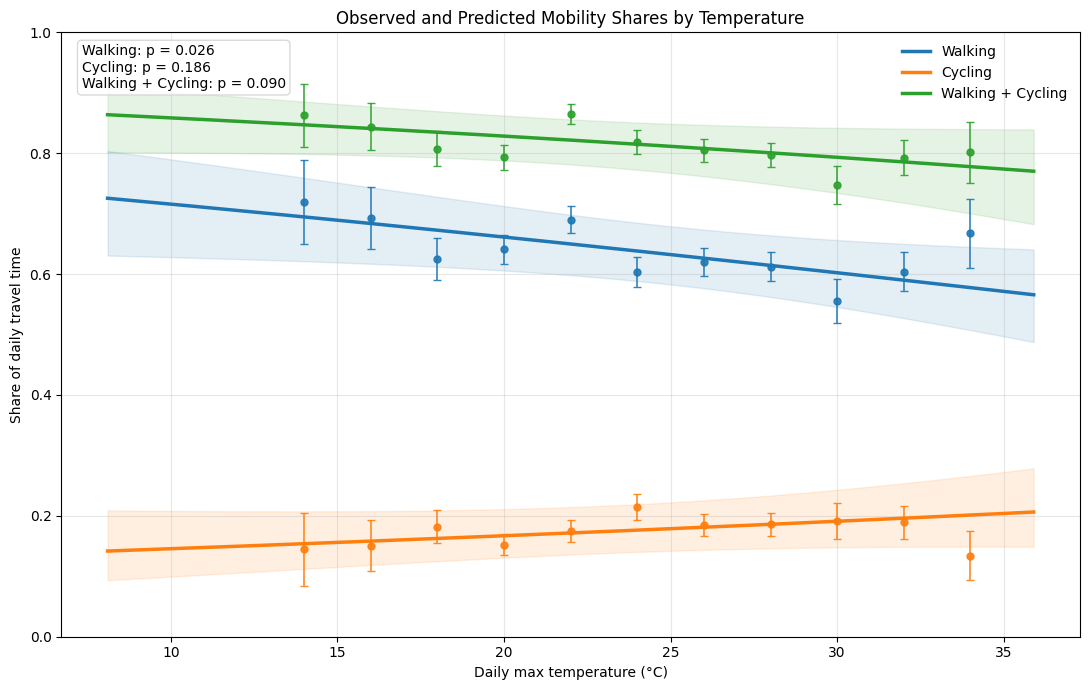

In [741]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2°C bins for observed summaries
bin_width = 2
daily_plot = daily.copy()
daily_plot["temp_bin_2"] = (np.floor(daily_plot["max_temp"] / bin_width) * bin_width).astype(int)

ratio_specs = {
    "walk_ratio": {
        "label": "Walking",
        "color": "C0",
        "pvalue": results["walk_ratio"].pvalues["max_temp"],
    },
    "bike_ratio": {
        "label": "Cycling",
        "color": "C1",
        "pvalue": results["bike_ratio"].pvalues["max_temp"],
    },
    "active_ratio": {
        "label": "Walking + Cycling",
        "color": "C2",
        "pvalue": results["active_ratio"].pvalues["max_temp"],
    },
}

# Prediction grid
temps = np.linspace(daily_plot["max_temp"].min(), daily_plot["max_temp"].max(), 300)
pred_df = pd.DataFrame({"max_temp": temps})

fig, ax = plt.subplots(figsize=(11, 7))

annotation_lines = []

for ratio, spec in ratio_specs.items():
    model = results[ratio]
    color = spec["color"]
    label = spec["label"]

    # Predicted curve
    pred = model.get_prediction(pred_df).summary_frame()

    ax.plot(
        temps,
        pred["mean"],
        color=color,
        linewidth=2.5,
        label=label,
        zorder=3,
    )

    ax.fill_between(
        temps,
        pred["mean_ci_lower"],
        pred["mean_ci_upper"],
        color=color,
        alpha=0.12,
        zorder=1,
    )

    # Observed binned means + SE
    obs = (
        daily_plot.groupby("temp_bin_2")[ratio]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    obs = obs[obs["count"] >= 10].copy()
    obs["se"] = obs["std"] / np.sqrt(obs["count"])

    ax.errorbar(
        obs["temp_bin_2"],
        obs["mean"],
        yerr=obs["se"],
        fmt="o",
        color=color,
        ecolor=color,
        elinewidth=1.2,
        capsize=3,
        markersize=5,
        alpha=0.9,
        zorder=4,
    )

    p = spec["pvalue"]
    annotation_lines.append(f"{label}: p = {p:.3f}")

ax.set_xlabel("Daily max temperature (°C)")
ax.set_ylabel("Share of daily travel time")
ax.set_title("Observed and Predicted Mobility Shares by Temperature")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(frameon=False)

# Small annotation box
ax.text(
    0.02,
    0.98,
    "\n".join(annotation_lines),
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="lightgray"),
)

plt.tight_layout()
plt.show()

Threshold: 1000 m - β: -0.026, p-value: 0.010
                 Generalized Linear Model Regression Results                  
Dep. Variable:             walk_ratio   No. Observations:                 1633
Model:                            GLM   Df Residuals:                     1631
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -878.17
Date:                Tue, 24 Mar 2026   Deviance:                       1231.8
Time:                        10:42:34   Pearson chi2:                 1.03e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.003022
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Interc

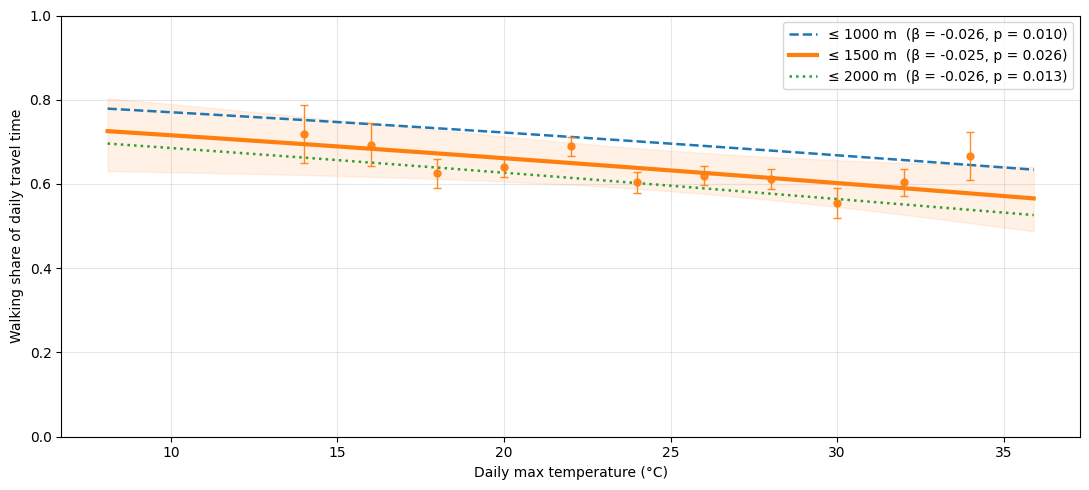

In [742]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Settings
thresholds = [1000, 1500, 2000]
main_threshold = 1500 # This corresponds roughly to the 90th percentile of walking trip distances. TODO: check if this is a common threshold for walkable trips in the literature

bin_width = 2
min_bin_count = 10
min_trips_per_day = 2

colors = {
    1000: "C0",
    1500: "C1",
    2000: "C2",
}

line_widths = {
    1000: 1.8,
    1500: 3.0,
    2000: 1.8,
}

line_styles = {
    1000: "--",
    1500: "-",
    2000: ":",
}

# -----------------------------
# Base data prep
# -----------------------------
df_plot = movements.copy()

df_plot["month"] = pd.to_datetime(df_plot["date"]).dt.month
df_plot = df_plot[df_plot["month"].isin([6, 7, 8, 9])].copy()

df_plot["start_time"] = pd.to_datetime(df_plot["start_time"], errors="coerce")
df_plot["end_time"] = pd.to_datetime(df_plot["end_time"], errors="coerce")
df_plot["duration"] = (df_plot["end_time"] - df_plot["start_time"]).dt.total_seconds()

df_plot = df_plot[df_plot["duration"].notna() & (df_plot["duration"] > 0)].copy()

person_day_max = build_person_day_max_temp_from_cache(df_plot, gh_prec=6)
df_plot = df_plot.merge(person_day_max, on=["participant_id", "date"], how="left")
df_plot = df_plot.dropna(subset=["max_temp"])

df_plot["walk_duration"] = np.where(df_plot["mean_of_transport"] == "Walking", df_plot["duration"], 0)

# shared prediction grid
temps = np.linspace(df_plot["max_temp"].min(), df_plot["max_temp"].max(), 300)
pred_df = pd.DataFrame({"max_temp": temps})

fig, ax = plt.subplots(figsize=(11, 5))

for thr in thresholds:
    # Restrict to trips below threshold
    df_thr = df_plot[df_plot["distance(m)"] <= thr].copy()

    daily_thr = (
        df_thr.groupby(["participant_id", "date"], as_index=False)
        .agg(
            max_temp=("max_temp", "max"),
            total_duration=("duration", "sum"),
            walk_duration=("walk_duration", "sum"),
            total_trips=("mean_of_transport", "count"),
        )
    )

    daily_thr = daily_thr[
        (daily_thr["total_duration"] > 0)
        # uncomment to have a minimum number of trips per day, to avoid very sparse days where the walk ratio is either 0% or 100% by construction
        # & (daily_thr["total_trips"] >= min_trips_per_day)
    ].copy()

    if len(daily_thr) < 20:
        continue

    daily_thr["walk_ratio"] = daily_thr["walk_duration"] / daily_thr["total_duration"]
    daily_thr["temp_bin_2"] = (np.floor(daily_thr["max_temp"] / bin_width) * bin_width).astype(int)

    # Fit model (genralized linear model with binomial family for proportions, clustered standard errors by participant_id)
    model = smf.glm(
        "walk_ratio ~ max_temp",
        data=daily_thr,
        family=sm.families.Binomial()
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": daily_thr["participant_id"]}
    )

    # Print beta and p-value for model with the current threshold
    print(f"Threshold: {thr} m - β: {model.params['max_temp']:.3f}, p-value: {model.pvalues['max_temp']:.3f}")
    print(model.summary())

    # Predicted curve
    pred = model.get_prediction(pred_df).summary_frame()

    label = f"≤ {thr} m  (β = {model.params['max_temp']:.3f}, p = {model.pvalues['max_temp']:.3f})"
    if thr == main_threshold:
        label = f"≤ {thr} m  (β = {model.params['max_temp']:.3f}, p = {model.pvalues['max_temp']:.3f})"

    ax.plot(
        temps,
        pred["mean"],
        color=colors[thr],
        linewidth=line_widths[thr],
        linestyle=line_styles[thr],
        label=label,
        zorder=3,
    )

    # CI band only for main threshold
    if thr == main_threshold:
        ax.fill_between(
            temps,
            pred["mean_ci_lower"],
            pred["mean_ci_upper"],
            color=colors[thr],
            alpha=0.10,
            zorder=1,
        )

        # Observed binned means + SE only for main threshold
        obs = (
            daily_thr.groupby("temp_bin_2")["walk_ratio"]
            .agg(["mean", "std", "count"])
            .reset_index()
        )
        obs = obs[obs["count"] >= min_bin_count].copy()
        obs["se"] = obs["std"] / np.sqrt(obs["count"])

        ax.errorbar(
            obs["temp_bin_2"],
            obs["mean"],
            yerr=obs["se"],
            fmt="o",
            color=colors[thr],
            ecolor=colors[thr],
            elinewidth=1,
            capsize=3,
            markersize=5,
            alpha=0.9,
            zorder=4,
        )

ax.set_xlabel("Daily max temperature (°C)")
ax.set_ylabel("Walking share of daily travel time")
#ax.set_title("Walking Share vs Temperature for Walkable Trips")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [713]:
# Assign is_hot_day column to movements
def is_hot_day(row):
    pid = row["participant_id"]
    date = row["date"]
    if pid in hot_days:
        if date in hot_days[pid]:
            return True
    return False

movements["is_hot_day"] = movements.apply(is_hot_day, axis=1)

In [419]:
# Plot to show total distance per active person by mode of transport per day during week vs weekend
grouped = movements.groupby(["date", "participant_id", "mean_of_transport", "is_weekend", "is_hot_day"])["distance(m)"].sum()
grouped = grouped.reset_index()

# Remove DETECTION_ERROR
grouped = grouped[grouped['mean_of_transport'] != "DETECTION_ERROR"]

grouped

,date,participant_id,mean_of_transport,is_weekend,is_hot_day,distance(m)
0,2024-08-28,119817XU1,Bicycle,False,False,598
1,2024-08-28,119817XU1,Walking,False,False,254
2,2024-08-28,219935XE1,Bicycle,False,False,3108
3,2024-08-28,219935XE1,Train,False,False,66362
4,2024-08-29,119817XU1,Bicycle,False,False,4098
...,...,...,...,...,...,...
15882,2026-01-05,7F3MXU,Walking,False,False,1288
15883,2026-01-05,8G2B2C,Bicycle,False,False,669
15884,2026-01-05,8G2B2C,Walking,False,False,1761
15885,2026-01-05,9B11R1G,Bicycle,False,False,3030


In [420]:
# Split into short and long mode of transport (car and train -> long)
grouped_long = grouped[grouped['mean_of_transport'].isin(["Car", "Train"])]
grouped_plane = grouped[grouped['mean_of_transport'].isin(["Plane"])]
grouped_short = grouped[~grouped['mean_of_transport'].isin(["Car", "Train", "Plane", "Boat"])]

In [21]:
# Remove walks longer than 30km in one day
grouped_short = grouped_short[~((grouped_short['distance(m)'] >= 30000) & (grouped_short['mean_of_transport'] == "Walking"))]

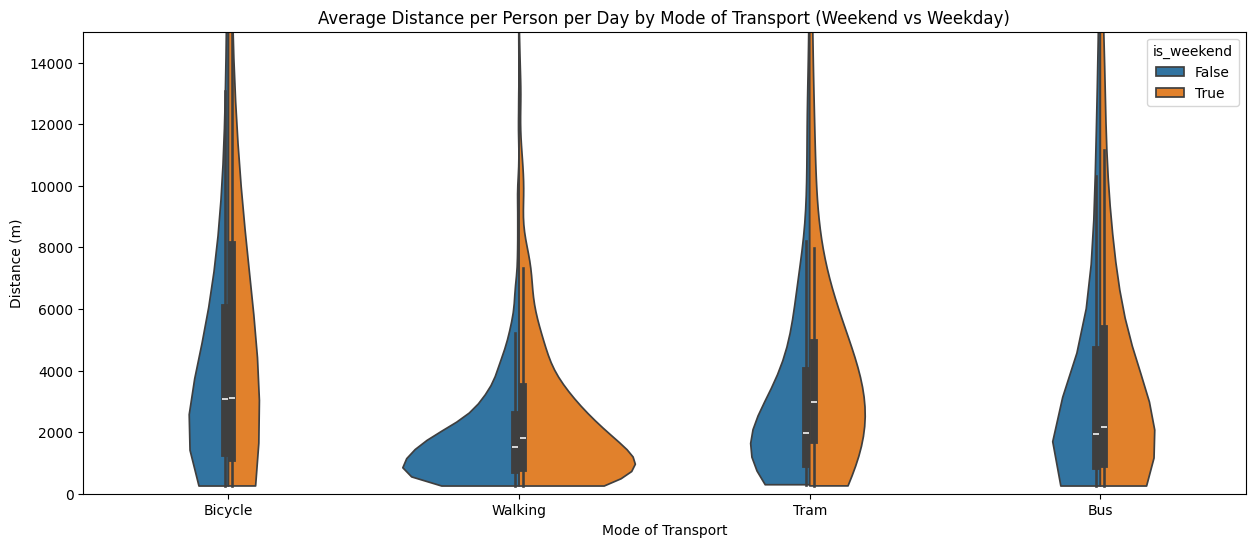

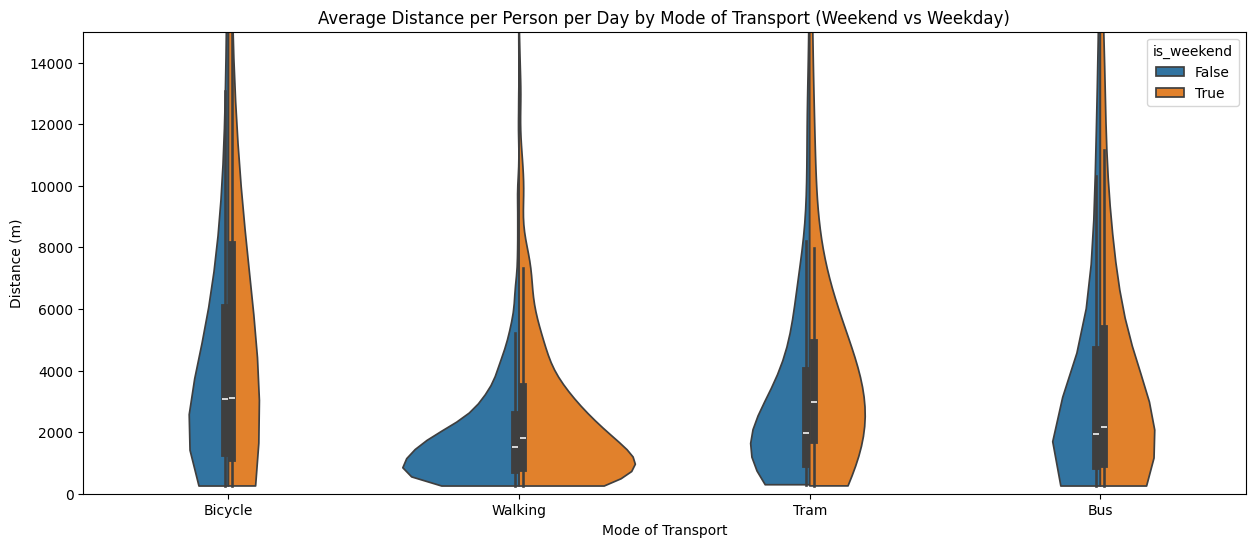

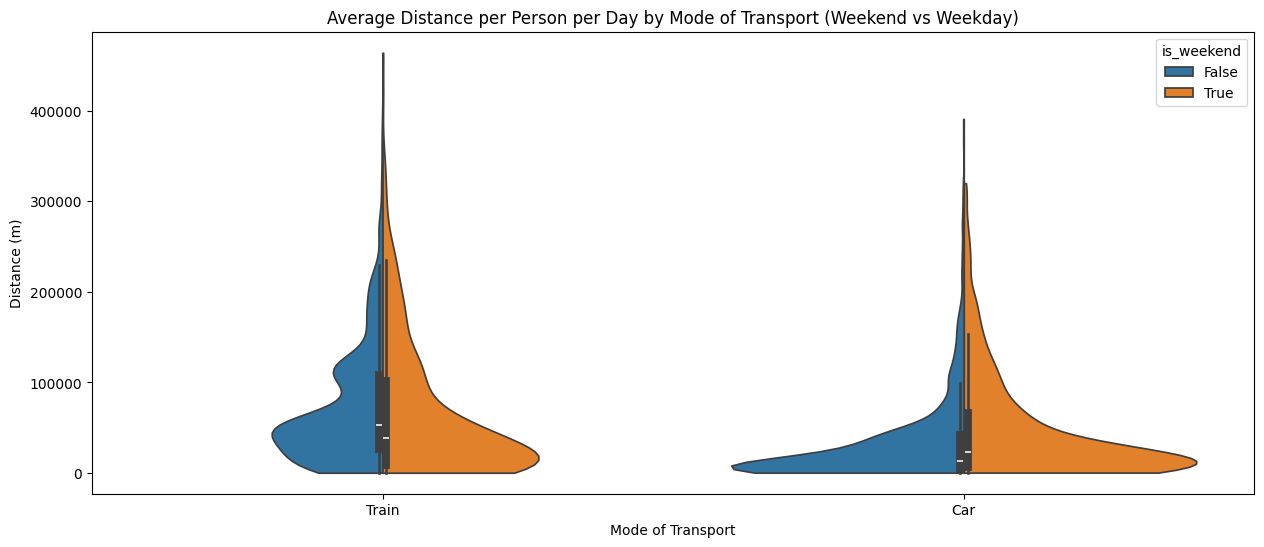

In [22]:
# Plot the results: violin plot of average distance per person per day by mode of transport and weekend vs weekday
import seaborn as sns
import matplotlib.pyplot as plt

for i, data in enumerate([grouped_short, grouped_long]):
    plt.figure(figsize=(15, 6))
    sns.violinplot(data=data, x="mean_of_transport", y="distance(m)", hue="is_weekend", split=True, cut=0)
    plt.title("Average Distance per Person per Day by Mode of Transport (Weekend vs Weekday)")
    plt.xlabel("Mode of Transport")
    plt.ylabel("Distance (m)")
    if i == 0:
        plt.ylim(0, 15000)
    #plt.yscale("log")
    #plt.legend(title="Is Weekend", labels=["Weekday", "Weekend"])
    plt.show()

In [23]:
def fractional_hours(df, start_col="start_time", end_col="end_time"):
    """
    Returns a new DataFrame where each original row is expanded into one row per
    overlapping hour bin, with weight = fraction of that hour occupied.

    Assumes start_time/end_time are timezone-consistent pandas Timestamps.
    Handles trips crossing midnight.
    """
    out_rows = []

    for idx, row in df.iterrows():
        start = row[start_col]
        end = row[end_col]

        if pd.isna(start) or pd.isna(end) or end <= start:
            continue

        # Iterate hour bins from floor(start) to end
        cur = start.floor("h")
        while cur < end:
            bin_start = cur
            bin_end = cur + pd.Timedelta(hours=1)

            overlap_start = max(start, bin_start)
            overlap_end = min(end, bin_end)

            overlap_sec = (overlap_end - overlap_start).total_seconds()
            if overlap_sec > 0:
                new = row.to_dict()
                new["hour_of_day"] = int(bin_start.hour)
                new["weight"] = overlap_sec / 3600.0  # fraction of hour
                out_rows.append(new)

            cur = bin_end

    return pd.DataFrame(out_rows)


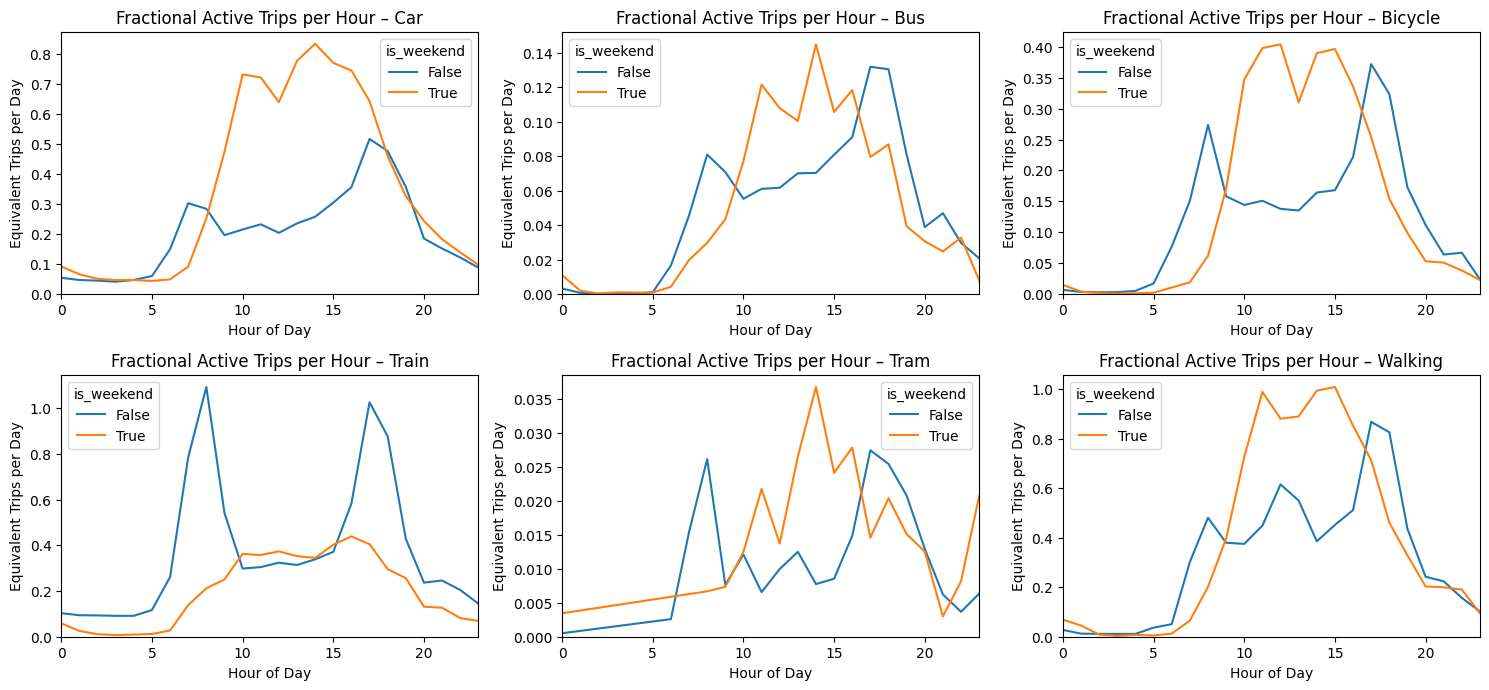

In [24]:
movements_f = movements.copy()

# Remove DETECTION_ERROR, Plane, Boat
movements_f = movements_f[movements_f["mean_of_transport"] != "DETECTION_ERROR"]
movements_f = movements_f[~movements_f["mean_of_transport"].isin(["Plane", "Boat"])]

movements_expanded = fractional_hours(movements_f, start_col="start_time", end_col="end_time")
# Compute the "activity volume" per each hour (considering that one trip spanning multiple hours counts fractionally in each hour during which the trip was not active for the full hour)
# For example, if a trip starts at 10:30 and ends at 12:15, it will count as 0.5 trips in hour 10, 1.0 trips in hour 11, and 0.25 trips in hour 12
hourly_active = (
    movements_expanded
    .groupby(["mean_of_transport", "is_weekend", "hour_of_day"])["weight"]
    .sum()
    .reset_index(name="equivalent_trips")
)

# Normalize per "observed days"
movements_expanded["date"] = movements_expanded["start_time"].dt.date
n_days = movements_expanded.groupby("is_weekend")["date"].nunique()

hourly_active["equivalent_trips_per_day"] = hourly_active.apply(
    lambda r: r["equivalent_trips"] / n_days[r["is_weekend"]],
    axis=1
)


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
modes = hourly_active["mean_of_transport"].unique()

for i, mot in enumerate(["Car", "Bus", "Bicycle", "Train", "Tram", "Walking"]):
    plt.subplot(3, 3, i + 1)
    sub = hourly_active[hourly_active["mean_of_transport"] == mot]

    sns.lineplot(
        data=sub,
        x="hour_of_day",
        y="equivalent_trips_per_day",
        hue="is_weekend"
    )

    plt.title(f"Fractional Active Trips per Hour – {mot}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Equivalent Trips per Day")
    plt.xlim(0, 23)
    plt.ylim(0)

plt.tight_layout()
plt.show()


In [25]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
import plotly.graph_objects as go

movements_f = movements.copy()

# Remove DETECTION_ERROR, Plane, Boat
movements_f = movements_f[movements_f["mean_of_transport"] != "DETECTION_ERROR"]
movements_f = movements_f[~movements_f["mean_of_transport"].isin(["Plane"])]

# Keep weekdays only
movements_f = movements_f[~movements_f["is_weekend"]]

# For each participant and date, get the average temperature of the movements on that day and assign it to all movements of that participant on that date
avg_temps = movements_f.groupby(["participant_id", "date"])["temperature"].mean().to_dict()

def assign_avg_temp(row):
    key = (row["participant_id"], row["date"])
    return avg_temps.get(key, np.nan)

movements_f["avg_temperature"] = movements_f.apply(assign_avg_temp, axis=1)

# Keep only temps > 0°C
movements_f = movements_f[(movements_f["avg_temperature"] >= 0.0)]

# Bin temperatures into 3°C intervals
movements_f["temp_bin"] = (movements_f["avg_temperature"] // 3) * 3 + 1  # Centers at 11, 13, 15, ...

movements_expanded = fractional_hours(movements_f, start_col="start_time", end_col="end_time")


# Compute the "activity volume" per each hour, now using temp_bin
hourly_active = (
    movements_expanded
    .groupby(["mean_of_transport", "temp_bin", "hour_of_day"])["weight"]
    .sum()
    .reset_index(name="equivalent_trips")
)

# Normalize per "observed days"
movements_expanded["date"] = movements_expanded["start_time"].dt.date
n_days = movements_expanded.groupby("temp_bin")["date"].nunique()

hourly_active["equivalent_trips_per_day"] = hourly_active.apply(
    lambda r: r["equivalent_trips"] / n_days[r["temp_bin"]],
    axis=1
)

mot = "Train"

# Filter for Walking only
bicycle_data = hourly_active[hourly_active["mean_of_transport"] == mot]

# Remove rows with NaN temperature
bicycle_data = bicycle_data.dropna(subset=["temp_bin"])

# Create grid for surface
hours = np.linspace(bicycle_data["hour_of_day"].min(), bicycle_data["hour_of_day"].max(), 50)
temps = np.linspace(bicycle_data["temp_bin"].min(), bicycle_data["temp_bin"].max(), 50)
hour_grid, temp_grid = np.meshgrid(hours, temps)

# Interpolate trips data onto grid
trips_grid = griddata(
    points=(bicycle_data["hour_of_day"], bicycle_data["temp_bin"]),
    values=bicycle_data["equivalent_trips_per_day"],
    xi=(hour_grid, temp_grid),
    method='cubic'
)

# Create interactive 3D surface plot with Plotly
fig = go.Figure()

# Add surface
fig.add_trace(go.Surface(
    x=hour_grid,
    y=temp_grid,
    z=trips_grid,
    colorscale='Viridis',
    opacity=0.9,
    name='Interpolated Surface',
    colorbar=dict(title='Trips per Day')
))

fig.update_layout(
    title=f'{mot} Usage by Hour and Average Temperature of the Daily Movements (Weekdays Only, 3°C bins)',
    scene=dict(
        xaxis_title='Hour of Day',
        yaxis_title='Avg. temperature of daily movements (°C)',
        zaxis_title='Equivalent Trips per Day'
    ),
    width=2000,
    height=1400
)

fig.show()


In [26]:
import numpy as np
from scipy.interpolate import griddata
import plotly.graph_objects as go

movements_f = movements.copy()

# Remove DETECTION_ERROR, Plane, Boat
movements_f = movements_f[movements_f["mean_of_transport"] != "DETECTION_ERROR"]
movements_f = movements_f[~movements_f["mean_of_transport"].isin(["Plane"])]

# Keep weekdays only
movements_f = movements_f[~movements_f["is_weekend"]]

# For each participant and date, get the average temperature of the movements on that day and assign it to all movements of that participant on that date
avg_temps = movements_f.groupby(["participant_id", "date"])["temperature"].max().to_dict()

def assign_avg_temp(row):
    key = (row["participant_id"], row["date"])
    return avg_temps.get(key, np.nan)

movements_f["avg_temperature"] = movements_f.apply(assign_avg_temp, axis=1)

# Keep only temps > 0°C
movements_f = movements_f[(movements_f["avg_temperature"] >= 0.0)]

# Bin temperatures into 3°C intervals
movements_f["temp_bin"] = (movements_f["avg_temperature"] // 3) * 3 + 1  # Centers at 11, 13, 15, ...

movements_expanded = fractional_hours(movements_f, start_col="start_time", end_col="end_time")

# Compute the "activity volume" per each hour, now using temp_bin
hourly_active = (
    movements_expanded
    .groupby(["mean_of_transport", "temp_bin", "hour_of_day"])["weight"]
    .sum()
    .reset_index(name="equivalent_trips")
)

# Normalize per "observed days"
movements_expanded["date"] = movements_expanded["start_time"].dt.date
n_days = movements_expanded.groupby("temp_bin")["date"].nunique()

hourly_active["equivalent_trips_per_day"] = hourly_active.apply(
    lambda r: r["equivalent_trips"] / n_days[r["temp_bin"]],
    axis=1
)

mot = "Walking"

# Filter for Walking only
bicycle_data = hourly_active[hourly_active["mean_of_transport"] == mot]

# Remove rows with NaN temperature
bicycle_data = bicycle_data.dropna(subset=["temp_bin"])

# Create grid for surface
hours = np.linspace(bicycle_data["hour_of_day"].min(), bicycle_data["hour_of_day"].max(), 50)
temps = np.linspace(bicycle_data["temp_bin"].min(), bicycle_data["temp_bin"].max(), 50)
hour_grid, temp_grid = np.meshgrid(hours, temps)

# Optional: if cubic interpolation leaves gaps (NaNs), fill them with nearest
if np.isnan(trips_grid).any():
    trips_grid_nearest = griddata(
        points=(bicycle_data["hour_of_day"], bicycle_data["temp_bin"]),
        values=bicycle_data["equivalent_trips_per_day"],
        xi=(hour_grid, temp_grid),
        method="nearest"
    )
    trips_grid = np.where(np.isnan(trips_grid), trips_grid_nearest, trips_grid)

# Contour plot
fig = go.Figure()

fig.add_trace(go.Contour(
    x=hours,          # 1D x-axis (hour)
    y=temps,          # 1D y-axis (temp bins)
    z=trips_grid,     # 2D grid (len(temps) x len(hours))
    colorscale="Viridis",
    contours=dict(
        coloring="fill",   # "lines" for line-only
        showlabels=True,
        labelfont=dict(size=12)
    ),
    colorbar=dict(title="Trips per Day")
))

fig.update_layout(
    title=f'{mot} Usage by Hour and Average Temperature of the Daily Movements',
    xaxis_title="Hour of Day",
    yaxis_title="Avg. temperature of daily movements (°C)",
    width=1200,
    height=800
)

fig.show()


In [27]:
temperature_cache

{'u0qnnq2025-05-19': {'latitude': 47.486816,
  'longitude': 8.719212,
  'generationtime_ms': 0.18584728240966797,
  'utc_offset_seconds': 0,
  'timezone': 'GMT',
  'timezone_abbreviation': 'GMT',
  'elevation': 448.0,
  'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C'},
  'hourly': {'time': ['2025-05-19T00:00',
    '2025-05-19T01:00',
    '2025-05-19T02:00',
    '2025-05-19T03:00',
    '2025-05-19T04:00',
    '2025-05-19T05:00',
    '2025-05-19T06:00',
    '2025-05-19T07:00',
    '2025-05-19T08:00',
    '2025-05-19T09:00',
    '2025-05-19T10:00',
    '2025-05-19T11:00',
    '2025-05-19T12:00',
    '2025-05-19T13:00',
    '2025-05-19T14:00',
    '2025-05-19T15:00',
    '2025-05-19T16:00',
    '2025-05-19T17:00',
    '2025-05-19T18:00',
    '2025-05-19T19:00',
    '2025-05-19T20:00',
    '2025-05-19T21:00',
    '2025-05-19T22:00',
    '2025-05-19T23:00'],
   'temperature_2m': [11.0,
    10.5,
    9.8,
    9.2,
    8.8,
    9.5,
    12.0,
    14.1,
    16.4,
    18.6,
    20.2,


In [28]:
### Compute max temperature of the day at all locations along a movement and assign it to the movement instead of the average temperature
def get_daily_max_temp_geohash(geohash, date, gh_prec=6):
    gh = geohash[:gh_prec]
    cache_key = f"{gh}{date}"
    if cache_key in temperature_cache:
        entry = temperature_cache[cache_key]
        if 'hourly' in entry and 'temperature_2m' in entry['hourly']:
            return max(entry['hourly']['temperature_2m'])
    return np.nan

def build_person_day_max_temp_from_cache(movements, gh_prec=6):
    start_locs = (
        movements[["participant_id", "date", "start_geohash"]]
        .rename(columns={
            "start_geohash": "geohash"
        })
    )

    end_locs = (
        movements[["participant_id", "date", "end_geohash"]]
        .rename(columns={
            "end_geohash": "geohash"
        })
    )

    visited = pd.concat([start_locs, end_locs], ignore_index=True).drop_duplicates()
    visited = visited.dropna(subset=["participant_id", "date", "geohash"]).copy()

    visited["location_day_max_temp"] = visited.apply(
        lambda r: get_daily_max_temp_geohash(
            r["geohash"], r["date"], gh_prec=gh_prec
        ),
        axis=1
    )

    person_day_max = (
        visited.groupby(["participant_id", "date"], as_index=False)["location_day_max_temp"]
        .max()
        .rename(columns={"location_day_max_temp": "max_temp"})
    )

    return person_day_max

### Build heatmap of walking movements in temperature bins per number of trips starting at that time

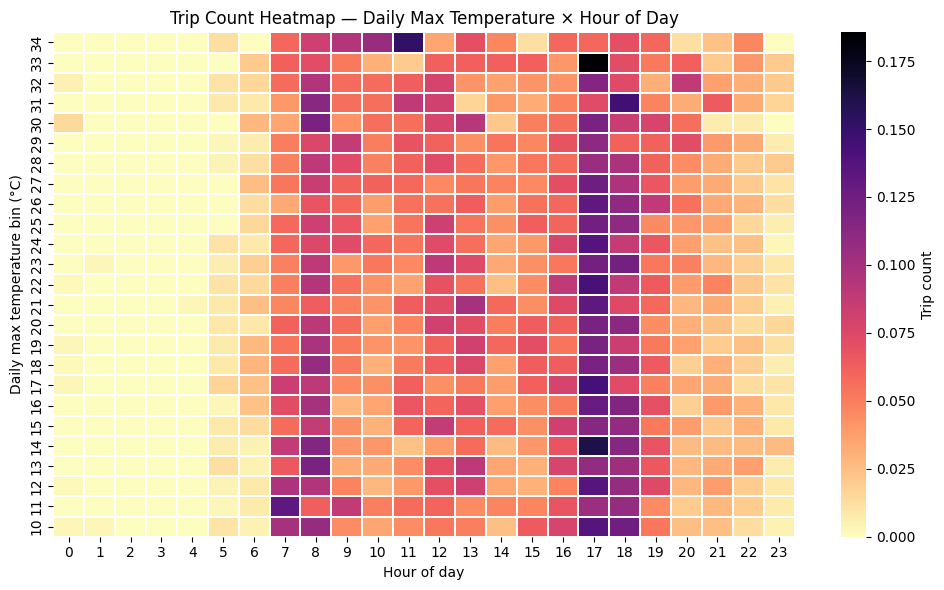

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df_h = movements.copy()
df_h = df_h.loc[~df_h["is_weekend"]].copy()
df_h["start_time"] = pd.to_datetime(df_h["start_time"], errors="coerce")

considered_mots = ["Walking", "Bicycle"]

# Only walking and cycling
df_h = df_h[df_h["mean_of_transport"].isin(considered_mots)].copy()

person_day_max = build_person_day_max_temp_from_cache(df_h, gh_prec=6)

df_h = df_h.merge(person_day_max, on=["participant_id", "date"], how="left")
df_h = df_h.dropna(subset=["max_temp"])

# Keep only data between 0 and 32°C
df_h = df_h[(df_h["max_temp"] >= 10.0) & (df_h["max_temp"] <= 40.0)].copy()

rng = 1
df_h["temp_bin"] = (df_h["max_temp"] // rng) * rng
df_h["temp_bin"] = df_h["temp_bin"].astype(int)

df_h["hour_bin"] = df_h["start_time"].dt.hour

heat = (
    df_h.groupby(["temp_bin", "hour_bin"])
    .size()
    .unstack(fill_value=0)
)

# For each temp_bin, normalize by the total number of trips in that temp_bin (so we get the distribution of trips across hours for each temp_bin, which allows us to see if the hour distribution changes with temperature)
heat = heat.div(heat.sum(axis=1), axis=0)

# Set bins with only 1 active day to 0 (since they are not representative)
active_days_per_bin = df_h.groupby("temp_bin")["date"].nunique()
heat = heat[active_days_per_bin >= 2]

# Clip to 0.2
heat = heat.clip(upper=0.2)

heat.index = pd.to_numeric(heat.index, errors="coerce")
heat.columns = pd.to_numeric(heat.columns, errors="coerce")
heat = heat.sort_index(ascending=False)
heat = heat.reindex(sorted(heat.columns), axis=1)
# Force all hours 0–23 to exist
heat = heat.reindex(columns=range(24), fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    heat,
    cmap="magma_r",
    linewidths=0.2,
    ax=ax,
    cbar_kws={"label": "Trip count"}
)

ax.set_title("Trip Count Heatmap — Daily Max Temperature × Hour of Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Daily max temperature bin (°C)")

plt.tight_layout()
plt.show()

In [30]:
movements.head()

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,duration,dow,is_weekend,date,temperature,is_hot,is_hot_day
0,0H2T3S,2025-01-28 17:07:52+01:00,2025-01-28 17:53:06+01:00,u0mgth,u0qjd2,49134,Train,Train,343,False,0 days 00:45:14,1,False,2025-01-28,3.9,False,False
1,0H2T3S,2025-01-28 17:57:29+01:00,2025-01-28 18:01:17+01:00,u0qjd2,u0qj6w,1581,Walking,Walking,0,False,0 days 00:03:48,1,False,2025-01-28,4.3,False,False
2,0H2T3S,2025-01-28 18:03:28+01:00,2025-01-28 18:34:50+01:00,u0qj6w,u0qj5x,8568,Bus,Bus,1130,False,0 days 00:31:22,1,False,2025-01-28,3.0,False,False
3,0H2T3S,2025-01-28 18:34:51+01:00,2025-01-28 18:48:06+01:00,u0qj5x,u0qj78,471,Walking,Walking,0,False,0 days 00:13:15,1,False,2025-01-28,2.2,False,False
4,0L3S1J,2025-05-23 11:54:16+02:00,2025-05-23 12:02:25+02:00,u0qnnq,u0qnnr,681,Walking,Walking,0,False,0 days 00:08:09,4,False,2025-05-23,12.4,False,False


### Same thing but using trip duration

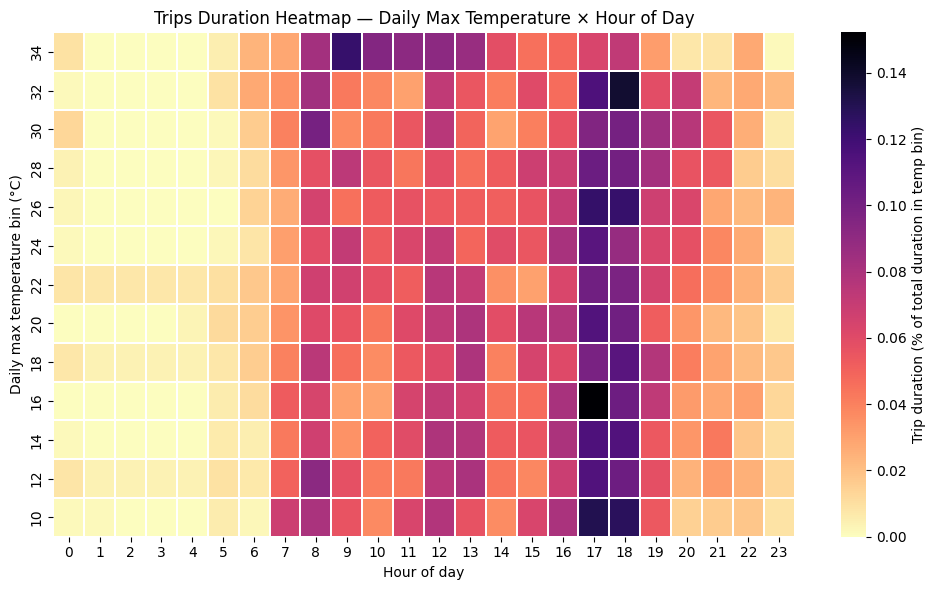

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

what_temp = "max_temp" # temperature for temperature uring the trip, or max_temp for the max temperature of the day at all locations along the trip
rng = 2

df_h = movements.copy()

df_h = df_h.loc[~df_h["is_weekend"]].copy()

df_h["start_time"] = pd.to_datetime(df_h["start_time"], errors="coerce")
df_h["end_time"] = pd.to_datetime(df_h["end_time"], errors="coerce")

# duration in seconds
df_h["duration"] = (df_h["end_time"] - df_h["start_time"]).dt.total_seconds()

# Remove small durations (e.g., less than 5 minutes) which are likely noise
#df_h = df_h[df_h["duration"] >= 5 * 60].copy()

# Only walking and cycling
df_h = df_h[df_h["mean_of_transport"].isin(["Walking", "Bicycle"])].copy()

person_day_max = build_person_day_max_temp_from_cache(df_h, gh_prec=6)

df_h = df_h.merge(person_day_max, on=["participant_id", "date"], how="left")
df_h = df_h.dropna(subset=[what_temp])

# Keep only data between 10 and 40°C
df_h = df_h[(df_h[what_temp] >= 10) & (df_h[what_temp] <= 40.0)].copy()

df_h["temp_bin"] = (df_h[what_temp] // rng) * rng
df_h["temp_bin"] = df_h["temp_bin"].astype(int)


def split_trip_into_hour_bins(row):
    start = row["start_time"]
    end = row["end_time"]

    if pd.isna(start) or pd.isna(end) or end <= start:
        return []

    out = []

    # Beginning of the hour containing start
    current_hour_start = start.floor("h")

    while current_hour_start < end:
        next_hour_start = current_hour_start + pd.Timedelta(hours=1)

        overlap_start = max(start, current_hour_start)
        overlap_end = min(end, next_hour_start)

        overlap_seconds = (overlap_end - overlap_start).total_seconds()

        if overlap_seconds > 0:
            out.append({
                "temp_bin": row["temp_bin"],
                "hour_bin": current_hour_start.hour,
                "duration_in_hour": overlap_seconds,
                "date": row["date"],
            })

        current_hour_start = next_hour_start

    return out


# Split each trip across all overlapping hours
expanded = []
for _, row in df_h.iterrows():
    expanded.extend(split_trip_into_hour_bins(row))

df_hourly = pd.DataFrame(expanded)

heat = (
    df_hourly.groupby(["temp_bin", "hour_bin"])["duration_in_hour"]
    .sum()
    .unstack(fill_value=0)
)

# Normalize within each temperature bin
heat = heat.div(heat.sum(axis=1), axis=0)

# Keep only temp bins with at least 2 active days
active_days_per_bin = df_h.groupby("temp_bin")["date"].nunique()
heat = heat[active_days_per_bin >= 2]

heat.index = pd.to_numeric(heat.index, errors="coerce")
heat.columns = pd.to_numeric(heat.columns, errors="coerce")
heat = heat.sort_index(ascending=False)
heat = heat.reindex(sorted(heat.columns), axis=1)

# Force all hours 0–23 to exist
heat = heat.reindex(columns=range(24), fill_value=0)

# Clip to 0.2
heat = heat.clip(upper=0.2)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    heat,
    cmap="magma_r",
    linewidths=0.2,
    ax=ax,
    cbar_kws={"label": "Trip duration (% of total duration in temp bin)"}
)

ax.set_title("Trips Duration Heatmap — Daily Max Temperature × Hour of Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Daily max temperature bin (°C)")

plt.tight_layout()
plt.show()

hour_bin,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
temp_bin,,,,,,,,,,,,,,,,,,,,,
10,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.071757,0.256378,0.191441,0.430869,...,0.314896,0.614657,0.689553,0.659759,0.455941,0.438528,0.165622,0.280112,0.392280,0.473091
12,0.028821,0.000000,0.000000,0.000000,0.000000,0.319515,0.075546,0.222218,0.272115,0.750665,...,0.813023,0.768248,0.769756,0.538718,0.395736,0.402912,0.500898,0.570251,0.665439,0.660650
14,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.165213,0.291915,0.286025,0.273509,...,1.000000,0.648942,0.461576,0.398820,0.503434,0.415648,0.712752,1.000000,0.429876,0.562489
16,0.000247,0.000000,0.000000,0.000000,0.000000,0.066951,0.072670,0.205168,0.187297,0.292578,...,0.565687,0.477543,0.486854,0.398047,0.430009,0.435793,0.479892,0.331569,0.333300,0.217517
18,0.635205,0.330822,0.333333,0.333333,0.333333,0.329482,0.120441,0.205651,0.292394,0.411077,...,0.355354,0.437084,0.558164,0.333204,0.391649,0.456130,0.326677,0.517379,0.330980,0.514449
20,0.000000,0.000000,0.000000,0.000000,0.000000,0.054188,0.027111,0.205142,0.298117,0.351161,...,0.372179,0.504880,0.265658,0.354818,0.302030,0.258676,0.348562,0.175608,0.228161,0.099717
22,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.323038,0.298150,0.452479,0.627527,...,0.525390,0.507932,0.452998,0.416872,0.596949,0.948367,0.825832,0.692352,0.771825,0.913334
24,0.128166,0.000000,0.000000,0.000000,0.000000,0.020839,0.048419,0.170933,0.266785,0.627055,...,0.405889,0.270910,0.367798,0.271563,0.360931,0.368965,0.351087,0.450641,0.445264,0.318438
26,1.000000,0.000000,0.000000,0.000000,0.000000,0.074747,0.099286,0.183936,0.271569,0.343509,...,0.354990,0.361056,0.294788,0.333077,0.427500,0.585701,0.695911,0.296757,0.217036,0.898705


hour_bin,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
temp_bin,,,,,,,,,,,,,,,,,,,,,
10,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.071757,0.256378,0.191441,0.430869,...,0.314896,0.614657,0.689553,0.659759,0.455941,0.438528,0.165622,0.280112,0.392280,0.473091
12,0.028821,0.000000,0.000000,0.000000,0.000000,0.319515,0.075546,0.222218,0.272115,0.750665,...,0.813023,0.768248,0.769756,0.538718,0.395736,0.402912,0.500898,0.570251,0.665439,0.660650
14,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.165213,0.291915,0.286025,0.273509,...,1.000000,0.648942,0.461576,0.398820,0.503434,0.415648,0.712752,1.000000,0.429876,0.562489
16,0.000247,0.000000,0.000000,0.000000,0.000000,0.066951,0.072670,0.205168,0.187297,0.292578,...,0.565687,0.477543,0.486854,0.398047,0.430009,0.435793,0.479892,0.331569,0.333300,0.217517
18,0.635205,0.330822,0.333333,0.333333,0.333333,0.329482,0.120441,0.205651,0.292394,0.411077,...,0.355354,0.437084,0.558164,0.333204,0.391649,0.456130,0.326677,0.517379,0.330980,0.514449
20,0.000000,0.000000,0.000000,0.000000,0.000000,0.054188,0.027111,0.205142,0.298117,0.351161,...,0.372179,0.504880,0.265658,0.354818,0.302030,0.258676,0.348562,0.175608,0.228161,0.099717
22,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.323038,0.298150,0.452479,0.627527,...,0.525390,0.507932,0.452998,0.416872,0.596949,0.948367,0.825832,0.692352,0.771825,0.913334
24,0.128166,0.000000,0.000000,0.000000,0.000000,0.020839,0.048419,0.170933,0.266785,0.627055,...,0.405889,0.270910,0.367798,0.271563,0.360931,0.368965,0.351087,0.450641,0.445264,0.318438
26,1.000000,0.000000,0.000000,0.000000,0.000000,0.074747,0.099286,0.183936,0.271569,0.343509,...,0.354990,0.361056,0.294788,0.333077,0.427500,0.585701,0.695911,0.296757,0.217036,0.898705


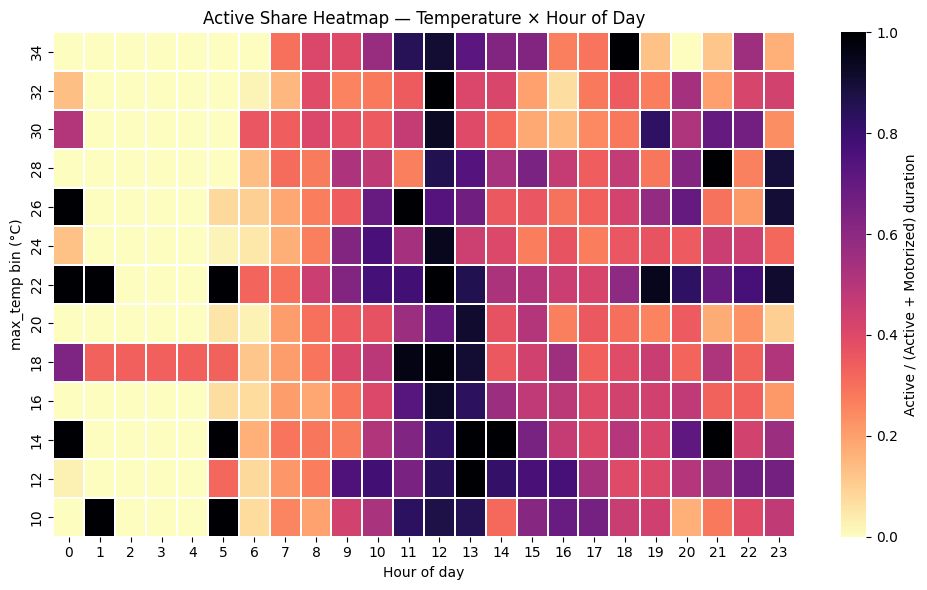

In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

what_temp = "max_temp"   # or another temperature column
rng = 2

ACTIVE_MODES = ["Walking"]


df_h = movements.copy()

df_h = df_h.loc[~df_h["is_weekend"]].copy()

df_h["start_time"] = pd.to_datetime(df_h["start_time"], errors="coerce")
df_h["end_time"] = pd.to_datetime(df_h["end_time"], errors="coerce")

# duration in seconds
df_h["duration"] = (df_h["end_time"] - df_h["start_time"]).dt.total_seconds()

# Keep only active + motorized trips
df_h["is_active"] = df_h["mean_of_transport"].isin(ACTIVE_MODES)
df_h["is_motorized"] = ~ df_h["mean_of_transport"].isin(ACTIVE_MODES)
df_h = df_h[df_h["is_active"] | df_h["is_motorized"]].copy()

person_day_max = build_person_day_max_temp_from_cache(df_h, gh_prec=6)

df_h = df_h.merge(person_day_max, on=["participant_id", "date"], how="left")
df_h = df_h.dropna(subset=[what_temp])

# Keep only data between 10 and 40°C
df_h = df_h[(df_h[what_temp] >= 10) & (df_h[what_temp] <= 40.0)].copy()

df_h["temp_bin"] = (df_h[what_temp] // rng) * rng
df_h["temp_bin"] = df_h["temp_bin"].astype(int)


def split_trip_into_hour_bins(row):
    start = row["start_time"]
    end = row["end_time"]

    if pd.isna(start) or pd.isna(end) or end <= start:
        return []

    out = []
    current_hour_start = start.floor("h")

    while current_hour_start < end:
        next_hour_start = current_hour_start + pd.Timedelta(hours=1)

        overlap_start = max(start, current_hour_start)
        overlap_end = min(end, next_hour_start)
        overlap_seconds = (overlap_end - overlap_start).total_seconds()

        if overlap_seconds > 0:
            out.append({
                "temp_bin": row["temp_bin"],
                "hour_bin": current_hour_start.hour,
                "duration_in_hour": overlap_seconds,
                "motorized_duration_in_hour": overlap_seconds if row["is_motorized"] else 0.0,
                "active_duration_in_hour": overlap_seconds if row["is_active"] else 0.0,
                "date": row["date"],
            })

        current_hour_start = next_hour_start

    return out


expanded = []
for _, row in df_h.iterrows():
    expanded.extend(split_trip_into_hour_bins(row))

df_hourly = pd.DataFrame(expanded)

# Denominator = active + motorized duration
total_heat = (
    df_hourly.groupby(["temp_bin", "hour_bin"])["duration_in_hour"]
    .sum()
    .unstack(fill_value=0)
)

motorized_heat = (
    df_hourly.groupby(["temp_bin", "hour_bin"])["motorized_duration_in_hour"]
    .sum()
    .unstack(fill_value=0)
)

# Numerator = active duration
active_heat = (
    df_hourly.groupby(["temp_bin", "hour_bin"])["active_duration_in_hour"]
    .sum()
    .unstack(fill_value=0)
)

# Ratio = active / (active + motorized)
heat = active_heat.div(motorized_heat).fillna(0).replace(np.inf, 0)

# Set values bigger than 5 to 0 (very big ratio likely means very little motorized duration, so the ratio is not representative)
heat = heat.where(heat <= 5, 0)

# Clip to 2.0
heat = heat.clip(upper=1.0)

display(heat)

# Keep only temp bins with at least 2 active days
active_days_per_bin = df_h.groupby("temp_bin")["date"].nunique()
heat = heat[active_days_per_bin >= 2]

heat.index = pd.to_numeric(heat.index, errors="coerce")
heat.columns = pd.to_numeric(heat.columns, errors="coerce")
heat = heat.sort_index(ascending=False)
heat = heat.reindex(sorted(heat.columns), axis=1)

# Force all hours 0–23 to exist
heat = heat.reindex(columns=range(24), fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    heat,
    cmap="magma_r",
    linewidths=0.2,
    #vmin=0,
    #vmax=1,
    ax=ax,
    cbar_kws={"label": "Active / (Active + Motorized) duration"}
)

ax.set_title("Active Share Heatmap — Temperature × Hour of Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel(f"{what_temp} bin (°C)")

plt.tight_layout()
plt.show()

/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_54470/1094850437.py:66: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_54470/1094850437.py:67: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



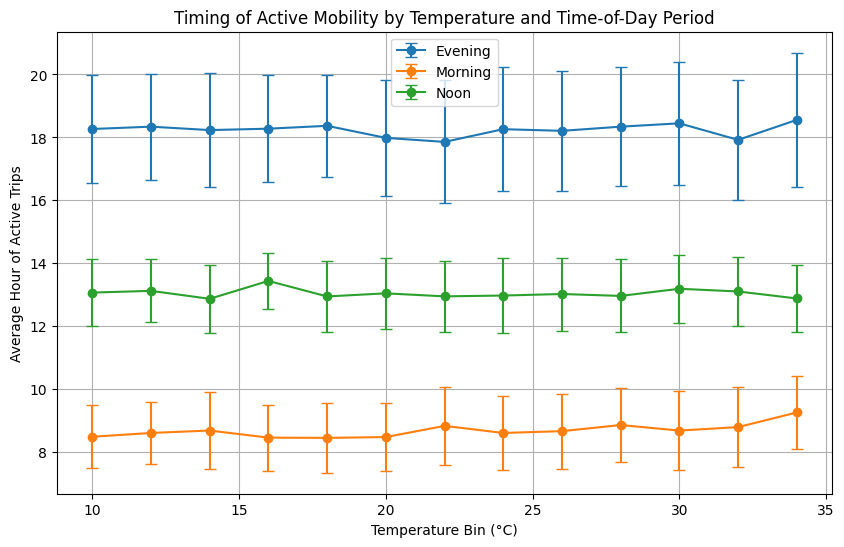

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_h = movements.copy()
df_h = df_h.loc[~df_h["is_weekend"]].copy()

rng = 2

df_h["start_time"] = pd.to_datetime(df_h["start_time"], errors="coerce")
df_h["end_time"] = pd.to_datetime(df_h["end_time"], errors="coerce")

ACTIVE_MODES = ["Walking"]
#df_h = df_h[df_h["mean_of_transport"].isin(ACTIVE_MODES)].copy()

person_day_max = build_person_day_max_temp_from_cache(df_h, gh_prec=6)
df_h = df_h.merge(person_day_max, on=["participant_id", "date"], how="left")
df_h = df_h.dropna(subset=[what_temp])
df_h = df_h[(df_h[what_temp] >= 10) & (df_h[what_temp] <= 40.0)].copy()

df_h["temp_bin"] = (df_h[what_temp] // rng) * rng
df_h["temp_bin"] = df_h["temp_bin"].astype(int)

# duration
df_h["duration"] = (df_h["end_time"] - df_h["start_time"]).dt.total_seconds()

# midpoint of trip
df_h["mid_time"] = df_h["start_time"] + (df_h["end_time"] - df_h["start_time"]) / 2

# fractional hour
df_h["hour_float"] = (
    df_h["mid_time"].dt.hour
    + df_h["mid_time"].dt.minute / 60
    + df_h["mid_time"].dt.second / 3600
)

# Define time-of-day segments
def classify_period(h):
    if 6 <= h < 11:
        return "Morning"
    elif 11 <= h < 15:
        return "Noon"
    elif 15 <= h < 23:
        return "Evening"
    else:
        return "Night"

df_h["period"] = df_h["hour_float"].apply(classify_period)

# weighted mean hour
def weighted_avg(group):
    w = group["duration"]
    if w.sum() == 0:
        return np.nan
    return (group["hour_float"] * w).sum() / w.sum()

# weighted std
def weighted_std(group):
    w = group["duration"]
    if w.sum() == 0:
        return np.nan
    avg = weighted_avg(group)
    var = (w * (group["hour_float"] - avg) ** 2).sum() / w.sum()
    return np.sqrt(var)

mean_hours = df_h.groupby(["period", "temp_bin"]).apply(weighted_avg)
std_hours = df_h.groupby(["period", "temp_bin"]).apply(weighted_std)

mean_hours = mean_hours.unstack(0)
std_hours = std_hours.unstack(0)

# Remove "Night" period since it is likely not representative (very few trips)
mean_hours = mean_hours.drop(columns=["Night"])
std_hours = std_hours.drop(columns=["Night"])

# Plot
plt.figure(figsize=(10,6))

for p in mean_hours.columns:
    plt.errorbar(
        mean_hours.index,
        mean_hours[p],
        yerr=std_hours[p],
        marker="o",
        capsize=4,
        label=p
    )

plt.xlabel("Temperature Bin (°C)")
plt.ylabel("Average Hour of Active Trips")
plt.title("Timing of Active Mobility by Temperature and Time-of-Day Period")
plt.grid()
plt.legend()
plt.show()

Spearman correlation between temp_bin and active trip ratio:
-0.04417110835427564 0.017233199834411808


<ErrorbarContainer object of 3 artists>

Spearman correlation between temp_bin and active trip ratio:
-0.04417110835427564 0.017233199834411808


<ErrorbarContainer object of 3 artists>

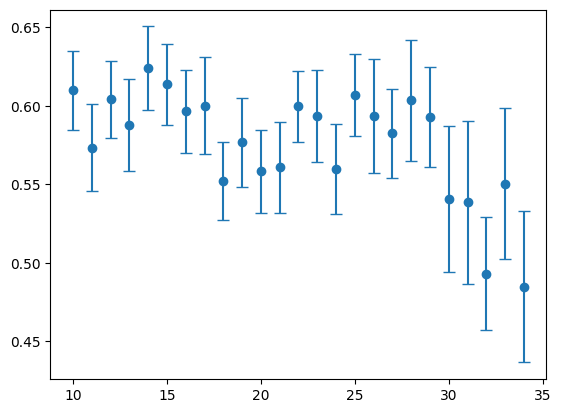

In [231]:

from scipy.stats import spearmanr

# Plot ratio of active trips to other trips by temperature bin (line plot with error bars, using the ratio per each participant_id...or per active day, both should be tested)
ACTIVE_MODES = ["Walking", "Bicycle"]

df = movements.copy()
df = df.loc[~df["is_weekend"]].copy()

rng = 1

person_day_max = build_person_day_max_temp_from_cache(df, gh_prec=6)

df = df.merge(person_day_max, on=["participant_id", "date"], how="left")
df = df.dropna(subset=[what_temp])

df = df[(df[what_temp] >= 10) & (df[what_temp] <= 40)].copy()

df["temp_bin"] = (df[what_temp] // rng) * rng
df["temp_bin"] = df["temp_bin"].astype(int)

df["is_active"] = df["mean_of_transport"].isin(ACTIVE_MODES)

# compute participant-day ratios
daily = (
    df.groupby(["participant_id","date","temp_bin"])
      .agg(
          total_trips=("mean_of_transport","count"),
          active_trips=("is_active","sum")
      )
      .reset_index()
)

daily["ratio"] = daily["active_trips"] / daily["total_trips"]

print("Spearman correlation between temp_bin and active trip ratio:")
rho, p = spearmanr(daily["temp_bin"], daily["ratio"])
print(rho, p)

# aggregate by temperature bin
stats = (
    daily.groupby("temp_bin")["ratio"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        n="count",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
)

stats["se"] = stats["std"] / np.sqrt(stats["n"])

# Keep only bins with at least 20 participant-days
stats = stats[stats["n"] >= 20]

plt.errorbar(
    stats.index,
    stats["mean"],
    yerr=stats["se"],
    fmt="o",
    capsize=4
)

In [329]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df = movements.copy()
#df = df.loc[~df["is_weekend"]].copy()

rng = 1

df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce")

# duration in seconds
df["duration"] = (df["end_time"] - df["start_time"]).dt.total_seconds()

# keep only valid durations
df = df[df["duration"].notna()].copy()
df = df[df["duration"] > 0].copy()

person_day_max = build_person_day_max_temp_from_cache(df, gh_prec=6)

df = df.merge(person_day_max, on=["participant_id", "date"], how="left")
df = df.dropna(subset=[what_temp])

df = df[(df[what_temp] >= 10) & (df[what_temp] <= 40)].copy()

df["temp_bin"] = (df[what_temp] // rng) * rng
df["temp_bin"] = df["temp_bin"].astype(int)

df["is_walk"] = df["mean_of_transport"] == "Walking"
df["is_bike"] = df["mean_of_transport"] == "Bicycle"

df["walk_duration"] = np.where(df["is_walk"], df["duration"], 0)
df["bike_duration"] = np.where(df["is_bike"], df["duration"], 0)

# duration contributed by active modes only
df["active_duration"] = df["walk_duration"] + df["bike_duration"]

daily = (
    df.groupby(["participant_id","date"])
      .agg(
          max_temp=("max_temp","first"),
          temp_bin=("temp_bin","first"),
          total_duration=("duration","sum"),
          walk_duration=("walk_duration","sum"),
          bike_duration=("bike_duration","sum"),
          total_trips=("mean_of_transport","count")
      )
      .reset_index()
)


# keep only participant-days with enough total movement duration
# example: at least 10 minutes of movement in the day
#daily = daily[daily["total_duration"] >= 10 * 60].copy()

daily["walk_ratio"] = daily["walk_duration"] / daily["total_duration"]
daily["bike_ratio"] = daily["bike_duration"] / daily["total_duration"]
daily["active_ratio"] = (daily["walk_duration"] + daily["bike_duration"]) / daily["total_duration"]

ratios = ["walk_ratio", "bike_ratio", "active_ratio"]

stats = {}

for r in ratios:
    s = (
        daily.groupby("temp_bin")[r]
        .agg(
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            mean="mean",
            std="std",
            n="count"
        )
    )

    s["se"] = s["std"] / np.sqrt(s["n"])
    s = s[s["n"] >= 20]
    stats[r] = s

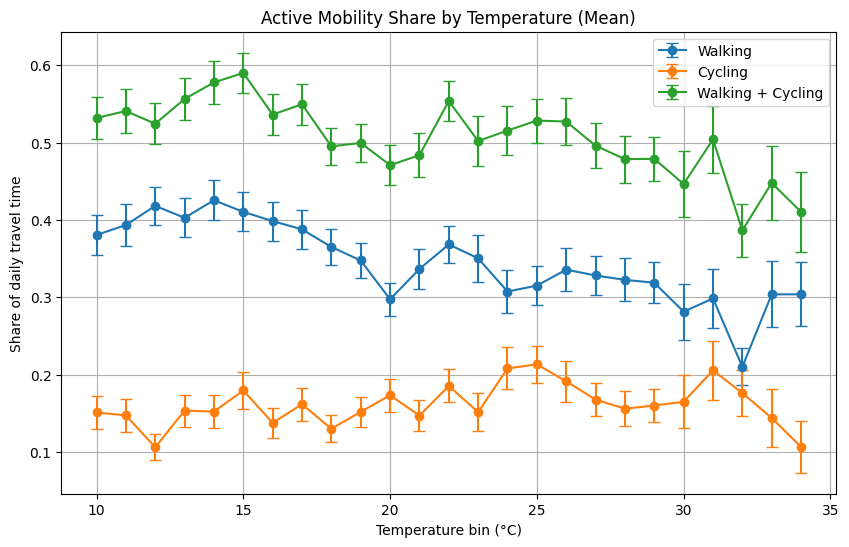

In [330]:
plt.figure(figsize=(10,6))

whatplot = "Mean"  # or "mean"

labels = {
    "walk_ratio": "Walking",
    "bike_ratio": "Cycling",
    "active_ratio": "Walking + Cycling"
}

for r in ratios:
    s = stats[r]

    if whatplot == "Mean":
        plt.errorbar(
            s.index,
            s["mean"],
            yerr=s["se"],
            marker="o",
            capsize=4,
            label=labels[r]
        )
    else:
        plt.errorbar(
            s.index,
            s["median"],
            yerr=[s["median"] - s["q25"], s["q75"] - s["median"]],
            marker="o",
            capsize=4,
            label=labels[r]
        )

plt.xlabel("Temperature bin (°C)")
plt.ylabel("Share of daily travel time")
plt.title(f"Active Mobility Share by Temperature ({whatplot})")
plt.legend()
plt.grid()
plt.show()

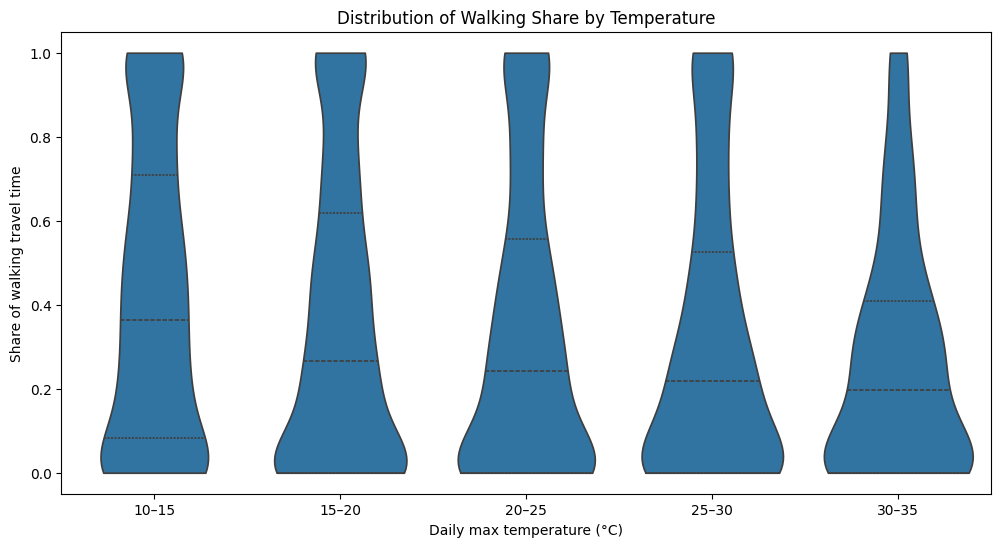

In [331]:
daily["temp_group"] = pd.cut(
    daily["temp_bin"],
    bins=[10,15,20,25,30,35],
    labels=["10–15","15–20","20–25","25–30","30–35"]
)

import seaborn as sns

plt.figure(figsize=(12,6))

sns.violinplot(
    data=daily,
    x="temp_group",
    y="walk_ratio",
    inner="quartile",
    cut=0
)

plt.xlabel("Daily max temperature (°C)")
plt.ylabel("Share of walking travel time")
plt.title("Distribution of Walking Share by Temperature")
plt.show()

In [361]:
thresh = 25
daily["temp_hot"] = (daily["max_temp"] - thresh).clip(lower=0)


 walk_ratio
                 Generalized Linear Model Regression Results                  
Dep. Variable:             walk_ratio   No. Observations:                 3941
Model:                            GLM   Df Residuals:                     3938
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2115.5
Date:                Thu, 19 Mar 2026   Deviance:                       2419.1
Time:                        16:19:41   Pearson chi2:                 1.97e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.006689
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0765      0.285     -0

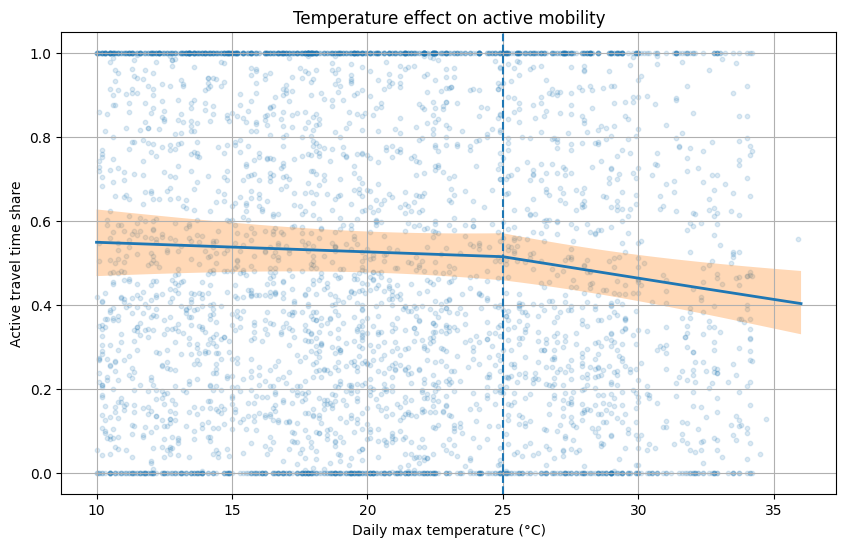

In [368]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

ratios = ["walk_ratio", "bike_ratio", "active_ratio"]
results = {}

for r in ratios:
    model = smf.glm(
        f"{r} ~ max_temp + temp_hot",
        data=daily,
        family=sm.families.Binomial()
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": daily["participant_id"]}
    )

    results[r] = model
    print("\n", r)
    print(model.summary())

import numpy as np
import pandas as pd

temps = np.linspace(10,36,200)

pred_df = pd.DataFrame({
    "max_temp": temps,
    "temp_hot": np.clip(temps-thresh,0,None)
})

pred = model.get_prediction(pred_df)
pred_summary = pred.summary_frame()

plt.figure(figsize=(10,6))

# raw participant-day data
plt.scatter(
    daily["max_temp"],
    daily["active_ratio"],
    alpha=0.15,
    s=10
)

# predicted curve
plt.plot(
    temps,
    pred_summary["mean"],
    linewidth=2
)

# confidence band
plt.fill_between(
    temps,
    pred_summary["mean_ci_lower"],
    pred_summary["mean_ci_upper"],
    alpha=0.3
)

plt.axvline(thresh, linestyle="--")

plt.xlabel("Daily max temperature (°C)")
plt.ylabel("Active travel time share")
plt.title("Temperature effect on active mobility")
plt.grid()
plt.show()

In [363]:
for r, model in results.items():
    print("\nMarginal effects:", r)
    print(model.get_margeff().summary())


Marginal effects: walk_ratio
         GLM Marginal Effects        
Dep. Variable:             walk_ratio
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
max_temp      -0.0057      0.003     -2.019      0.043      -0.011      -0.000
temp_hot      -0.0016      0.004     -0.372      0.710      -0.010       0.007

Marginal effects: bike_ratio
         GLM Marginal Effects        
Dep. Variable:             bike_ratio
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
max_temp       0.0036      0.003      1.319      0.187      -0.002       0.009
temp_hot      -0.0071      0.004     -1.668      0.095      -0.015       0.001

Mar

In [364]:
from scipy.stats import spearmanr

for r in ratios:
    rho, p = spearmanr(daily["max_temp"], daily[r])
    print(r, rho, p)

walk_ratio -0.1081504338075917 9.950164229878427e-12
bike_ratio 0.08704260075627655 4.425725961867754e-08
active_ratio -0.0738373866962577 3.4810192867855685e-06


In [365]:
melted = daily.melt(
    id_vars=["participant_id","date","max_temp"],
    value_vars=["walk_ratio","bike_ratio"],
    var_name="mode",
    value_name="ratio"
)

model = smf.glm(
    "ratio ~ max_temp * mode",
    data=melted,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": melted["participant_id"]}
)

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  ratio   No. Observations:                 7882
Model:                            GLM   Df Residuals:                     7878
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3651.7
Date:                Thu, 19 Mar 2026   Deviance:                       4630.1
Time:                        16:18:59   Pearson chi2:                 4.40e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05294
Covariance Type:              cluster                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [367]:
## Robustness check
import statsmodels.api as sm
import statsmodels.formula.api as smf

def run_model(min_trips):
    tmp = daily[daily["total_trips"] >= min_trips].copy()

    model = smf.glm(
        "active_ratio ~ max_temp",
        data=tmp,
        family=sm.families.Binomial()
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": tmp["participant_id"]}
    )

    return model.params["max_temp"], model.pvalues["max_temp"]

for t in [3,5,8,10]:
    coef, p = run_model(t)
    print(t, coef, p)

3 -0.019850534119875134 0.03727391530983481
5 -0.018059000738762845 0.09462212286607648
8 -0.009976249306429534 0.4447342998774132
10 -0.0016756334212276337 0.891915826053957


### Create heatmaps of locations visited during week and weekend (using paths data)


In [ ]:
paths.head()

,time_range,day_of_week,month,mode_of_transport,geohash,direction,mean_of_transport
0,18-21,TUESDAY,8,BUS,u0m70dcm,EAST,Bus
1,18-21,TUESDAY,8,BUS,u0m70ddq,NORTH_WEST,Bus
2,18-21,TUESDAY,8,BUS,u0m70dfh,EAST,Bus
3,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqv,NORTH_EAST,Bicycle
4,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqk,EAST,Bicycle


In [ ]:
paths["is_weekend"] = paths["day_of_week"].isin(["SATURDAY", "SUNDAY"])

In [ ]:
# Add latitude, longitude, and h3 to all path points
paths = paths.merge(geo_to_coords, on="geohash", how="left")

In [ ]:
paths['h3'] = paths.apply(lambda row: h3.latlng_to_cell(row['latitude'], row['longitude'], 8), axis=1)

In [ ]:
paths.head()

,time_range,day_of_week,month,mode_of_transport,geohash,direction,mean_of_transport,is_weekend,latitude,longitude,h3
0,18-21,TUESDAY,8,BUS,u0m70dcm,EAST,Bus,False,46.949644,7.406673,881f834257fffff
1,18-21,TUESDAY,8,BUS,u0m70ddq,NORTH_WEST,Bus,False,46.948442,7.408047,881f834257fffff
2,18-21,TUESDAY,8,BUS,u0m70dfh,EAST,Bus,False,46.949472,7.407703,881f834257fffff
3,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqv,NORTH_EAST,Bicycle,False,46.946898,7.425213,881f834211fffff
4,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqk,EAST,Bicycle,False,46.946726,7.424526,881f834211fffff


In [ ]:
# Add polygons for each h3 hexagon
paths['geometry'] = paths['h3'].apply(lambda h: geometry.Polygon(h3.cell_to_boundary(h)))
paths = gpd.GeoDataFrame(paths, geometry='geometry', crs="EPSG:4326")
# Invert latitude and longitude in geometry
paths['geometry'] = paths['geometry'].apply(lambda poly: geometry.Polygon([(coord[1], coord[0]) for coord in poly.exterior.coords]))

In [ ]:
# Add elevation to paths
dem = rasterio.open("data/switzerland_dem.tif")
paths['elevation'] = paths.apply(lambda row: get_elevation_at_point(row['longitude'], row['latitude'], dem), axis=1)

In [ ]:
# Remove rows with 0 elevation (outside DEM coverage)
paths = paths[paths['elevation'] != 0]

In [ ]:
# Get average elevation per h3 cell
paths = add_elevation_to_gdf(paths, "data/switzerland_dem.tif")

In [ ]:
paths.head()

,time_range,day_of_week,month,mode_of_transport,geohash,direction,mean_of_transport,is_weekend,latitude,longitude,h3,geometry,elevation,avg_elevation
0,18-21,TUESDAY,8,BUS,u0m70dcm,EAST,Bus,False,46.949644,7.406673,881f834257fffff,"POLYGON ((7.40618 46.95507, 7.40454 46.95049, ...",558,557.428571
1,18-21,TUESDAY,8,BUS,u0m70ddq,NORTH_WEST,Bus,False,46.948442,7.408047,881f834257fffff,"POLYGON ((7.40618 46.95507, 7.40454 46.95049, ...",549,557.428571
2,18-21,TUESDAY,8,BUS,u0m70dfh,EAST,Bus,False,46.949472,7.407703,881f834257fffff,"POLYGON ((7.40618 46.95507, 7.40454 46.95049, ...",555,557.428571
3,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqv,NORTH_EAST,Bicycle,False,46.946898,7.425213,881f834211fffff,"POLYGON ((7.42119 46.94623, 7.41955 46.94165, ...",548,546.428571
4,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqk,EAST,Bicycle,False,46.946726,7.424526,881f834211fffff,"POLYGON ((7.42119 46.94623, 7.41955 46.94165, ...",549,546.428571


In [ ]:
paths["elevation"].describe()

count    1.222860e+06
mean     5.833146e+02
std      3.121780e+02
min      1.910000e+02
25%      4.360000e+02
50%      4.840000e+02
75%      6.280000e+02
max      3.776000e+03
Name: elevation, dtype: float64

In [ ]:
paths["avg_elevation"].describe()

count    1.222860e+06
mean     5.949231e+02
std      3.157807e+02
min      1.910000e+02
25%      4.445714e+02
50%      5.004286e+02
75%      6.295714e+02
max      3.726000e+03
Name: avg_elevation, dtype: float64

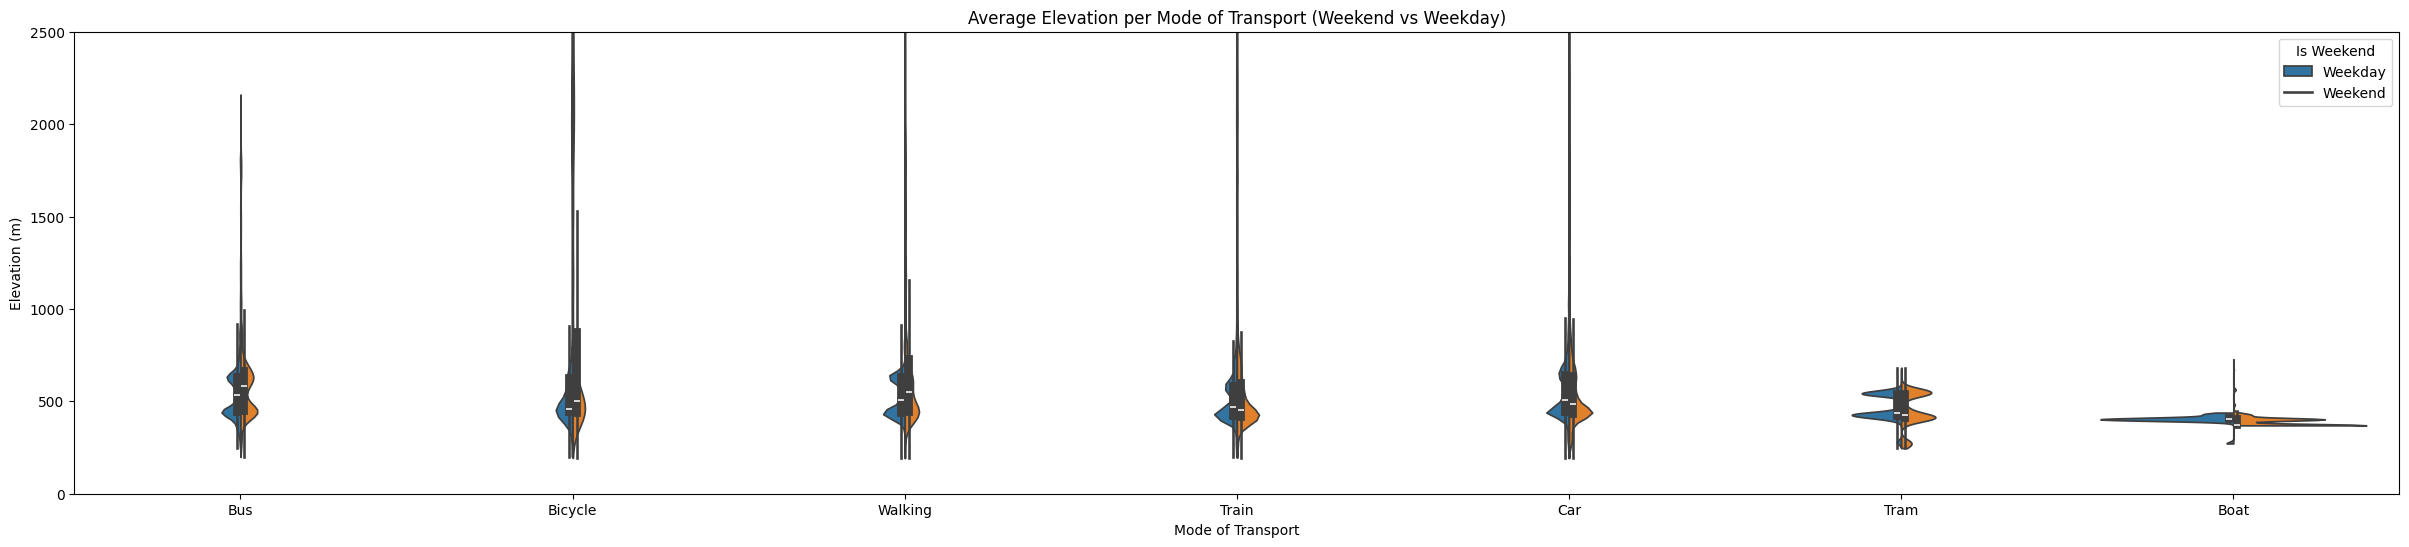

In [ ]:
# Plot altitude per mode of transport during weekday vs weekend in violin plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 6))
sns.violinplot(data=paths, x="mean_of_transport", y="elevation", hue="is_weekend", split=True, cut=0)
plt.title("Average Elevation per Mode of Transport (Weekend vs Weekday)")
plt.xlabel("Mode of Transport")
plt.ylabel("Elevation (m)")
plt.ylim(0, 2500)
plt.legend(title="Is Weekend", labels=["Weekday", "Weekend"])
plt.show()

In [ ]:
# Count presence in each geohash durign weekend vs weekday
paths["short_geohash"] = paths["geohash"].str.slice(0,7)
presence = paths.groupby(["short_geohash", "mean_of_transport", "is_weekend"]).size().reset_index(name="counts")
presence = presence.reset_index()
presence = presence.merge(geo_to_coords, left_on="short_geohash", right_on="geohash", how="left")
presence = presence.dropna(subset=["latitude", "longitude"])
presence["latitude"] = presence["latitude"].astype(float)
presence["longitude"] = presence["longitude"].astype(float)
presence

,index,short_geohash,mean_of_transport,is_weekend,counts,geohash,latitude,longitude
0,0,u0hnx8r,Train,False,1,u0hnx8r,46.144638,5.964890
1,1,u0hnxb8,Train,False,2,u0hnxb8,46.146011,5.966263
2,2,u0hnxcf,Train,False,1,u0hnxcf,46.152878,5.969009
3,3,u0hq8dd,Train,False,1,u0hq8dd,46.156998,6.001968
4,4,u0hq8qs,Train,True,1,u0hq8qs,46.178970,5.993729
...,...,...,...,...,...,...,...,...
204286,204286,u0r64n8,Train,True,2,u0r64n8,46.794205,10.283890
204287,204287,u0r64n9,Train,True,3,u0r64n9,46.794205,10.285263
204288,204288,u0r64nd,Train,True,2,u0r64nd,46.794205,10.286636
204289,204289,u0r64ne,Train,True,5,u0r64ne,46.794205,10.288010


In [ ]:
# Define plasma color map
plasma_colormap = [plt.cm.winter(i)[:3] for i in range(256)]  # Get 256 RGB values
plasma_colormap = [[int(r*255), int(g*255), int(b*255)] for r, g, b in plasma_colormap]  # Convert to 0-255

In [ ]:
# Display heatmap on map using pydeck (create two, one for weekend and one for weekday)
import pydeck as pdk

for day in ["weekend", "weekday"]:
    if day == "weekend":
        day_presence = presence[presence["is_weekend"] == True]
    else:
        day_presence = presence[presence["is_weekend"] == False]

    layer = pdk.Layer(
        'HeatmapLayer',
        day_presence,
        get_position=['longitude', 'latitude'],
        get_weight='counts',
        color_range=plasma_colormap,  # Apply Plasma colormap
        aggregation = 'SUM',
        opacity=0.8,
        pickable=True
    )

    view_state = pdk.ViewState(
        latitude=day_presence['latitude'].median(),
        longitude=day_presence['longitude'].median(),
        zoom=8,
        min_zoom=5,
        max_zoom=15,
    )

    r = pdk.Deck(
        layers=[layer],
        initial_view_state=view_state
    )

    r.to_html(f'maps/simple_analysis/heatmap_presence_{day}.html')

    ! open maps/simple_analysis/heatmap_presence_{day}.html

In [ ]:
# Weekend - Weekday difference, using bigger h3 hexagons
presence["h3"] = presence.apply(lambda row: h3.latlng_to_cell(row['latitude'], row['longitude'], 7), axis=1)
presence

,index,short_geohash,mean_of_transport,is_weekend,counts,geohash,latitude,longitude,h3
0,0,u0hnx8r,Train,False,1,u0hnx8r,46.144638,5.964890,871f91a9effffff
1,1,u0hnxb8,Train,False,2,u0hnxb8,46.146011,5.966263,871f91a9cffffff
2,2,u0hnxcf,Train,False,1,u0hnxcf,46.152878,5.969009,871f91a9cffffff
3,3,u0hq8dd,Train,False,1,u0hq8dd,46.156998,6.001968,871f91a9dffffff
4,4,u0hq8qs,Train,True,1,u0hq8qs,46.178970,5.993729,871f91a83ffffff
...,...,...,...,...,...,...,...,...,...
204286,204286,u0r64n8,Train,True,2,u0r64n8,46.794205,10.283890,871f8a8c1ffffff
204287,204287,u0r64n9,Train,True,3,u0r64n9,46.794205,10.285263,871f8a8c1ffffff
204288,204288,u0r64nd,Train,True,2,u0r64nd,46.794205,10.286636,871f8a8c1ffffff
204289,204289,u0r64ne,Train,True,5,u0r64ne,46.794205,10.288010,871f8a8c1ffffff


In [ ]:
# Adapt counts to the new h3 hexagons
h3_presence = presence.groupby(["h3", "is_weekend"])["counts"].sum().reset_index()
h3_presence

,h3,is_weekend,counts
0,871f80680ffffff,True,4
1,871f80683ffffff,True,4
2,871f80698ffffff,True,2
3,871f8069bffffff,True,3
4,871f8069cffffff,True,3
...,...,...,...
5698,871f9dd99ffffff,True,423
5699,871f9dd9bffffff,False,18
5700,871f9dd9bffffff,True,47
5701,871f9dd9dffffff,False,245


In [ ]:
# Get weekend - weekday presence difference in each h3 hexagon
weekend_presence = h3_presence[h3_presence["is_weekend"] == True][["h3", "counts"]].rename(columns={"counts": "weekend_counts"})
weekday_presence = h3_presence[h3_presence["is_weekend"] == False][["h3", "counts"]].rename(columns={"counts": "weekday_counts"})

presence_diff = weekend_presence.merge(weekday_presence, on="h3", how="outer").fillna(0)
presence_diff["presence_diff"] = presence_diff["weekend_counts"] - presence_diff["weekday_counts"]
presence_diff.describe()

,weekend_counts,weekday_counts,presence_diff
count,3462.000000,3462.000000,3462.000000
mean,112.266898,240.512132,-128.245234
std,440.509742,1467.920170,1081.204494
min,0.000000,0.000000,-46060.000000
25%,4.000000,2.000000,-46.000000
50%,30.000000,32.500000,-2.000000
75%,97.000000,122.000000,20.000000
max,12970.000000,59030.000000,1135.000000


In [ ]:
# Compute polygons for presence_diff
presence_diff_gdf = presence_diff.copy()
presence_diff_gdf['geometry'] = presence_diff_gdf['h3'].apply(lambda h: geometry.Polygon(h3.cell_to_boundary(h)))
presence_diff_gdf = gpd.GeoDataFrame(presence_diff_gdf, geometry='geometry', crs="EPSG:4326")
# Invert latitude and longitude in geometry
presence_diff_gdf['geometry'] = presence_diff_gdf['geometry'].apply(lambda poly: geometry.Polygon([(coord[1], coord[0]) for coord in poly.exterior.coords]))
presence_diff_gdf

,h3,weekend_counts,weekday_counts,presence_diff,geometry
0,871f80680ffffff,4.0,0.0,4.0,"POLYGON ((6.97702 47.48593, 6.97882 47.47391, ..."
1,871f80683ffffff,4.0,0.0,4.0,"POLYGON ((6.99557 47.46978, 6.99736 47.45777, ..."
2,871f80698ffffff,2.0,0.0,2.0,"POLYGON ((7.00095 47.43374, 7.00274 47.42172, ..."
3,871f8069bffffff,3.0,0.0,3.0,"POLYGON ((7.01948 47.41758, 7.02127 47.40555, ..."
4,871f8069cffffff,3.0,0.0,3.0,"POLYGON ((6.98241 47.44989, 6.98421 47.43787, ..."
...,...,...,...,...,...
3457,871f9dd8effffff,21.0,10.0,11.0,"POLYGON ((7.96304 46.41662, 7.96467 46.40441, ..."
3458,871f9dd98ffffff,77.0,50.0,27.0,"POLYGON ((7.93644 46.37654, 7.93807 46.36432, ..."
3459,871f9dd99ffffff,423.0,225.0,198.0,"POLYGON ((7.96792 46.37998, 7.96955 46.36776, ..."
3460,871f9dd9bffffff,47.0,18.0,29.0,"POLYGON ((7.95462 46.35993, 7.95625 46.34771, ..."


In [ ]:
# Decide colors: if presence_diff > 0 -> more presence during weekend (red), if < 0 -> more presence during weekday (use blue)
presence_diff_gdf['color'] = presence_diff_gdf['presence_diff'].apply(
    lambda x: [255, 0, 0, 255] if x > 10
    else [0, 0, 255, 255] if x < -20
    else [200, 200, 200, 0]
)

In [ ]:
presence_diff_gdf

,h3,weekend_counts,weekday_counts,presence_diff,geometry,color
0,871f80680ffffff,4.0,0.0,4.0,"POLYGON ((6.97702 47.48593, 6.97882 47.47391, ...","[200, 200, 200, 0]"
1,871f80683ffffff,4.0,0.0,4.0,"POLYGON ((6.99557 47.46978, 6.99736 47.45777, ...","[200, 200, 200, 0]"
2,871f80698ffffff,2.0,0.0,2.0,"POLYGON ((7.00095 47.43374, 7.00274 47.42172, ...","[200, 200, 200, 0]"
3,871f8069bffffff,3.0,0.0,3.0,"POLYGON ((7.01948 47.41758, 7.02127 47.40555, ...","[200, 200, 200, 0]"
4,871f8069cffffff,3.0,0.0,3.0,"POLYGON ((6.98241 47.44989, 6.98421 47.43787, ...","[200, 200, 200, 0]"
...,...,...,...,...,...,...
3457,871f9dd8effffff,21.0,10.0,11.0,"POLYGON ((7.96304 46.41662, 7.96467 46.40441, ...","[255, 0, 0, 255]"
3458,871f9dd98ffffff,77.0,50.0,27.0,"POLYGON ((7.93644 46.37654, 7.93807 46.36432, ...","[255, 0, 0, 255]"
3459,871f9dd99ffffff,423.0,225.0,198.0,"POLYGON ((7.96792 46.37998, 7.96955 46.36776, ...","[255, 0, 0, 255]"
3460,871f9dd9bffffff,47.0,18.0,29.0,"POLYGON ((7.95462 46.35993, 7.95625 46.34771, ...","[255, 0, 0, 255]"


In [ ]:
# Display on map using pydeck
layer = pdk.Layer(
    'GeoJsonLayer',
    presence_diff_gdf,
    filled=True,
    get_fill_color='color',
    opacity=0.2,
)

view_state = pdk.ViewState(
    latitude=day_presence['latitude'].median(),
    longitude=day_presence['longitude'].median(),
    zoom=8,
    min_zoom=2,
    max_zoom=15,
)

r = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state
)

r.to_html(f'maps/simple_analysis/weekend_only.html')

! open maps/simple_analysis/weekend_only.html

In [ ]:
import numpy as np
import geopandas as gpd

def polygon_vertex_centroid_points(poly):
    """
    Returns list of (x, y) = (lon, lat) points: polygon exterior vertices + centroid.
    """
    # exterior coords includes closing point = first point repeated -> drop last
    coords = list(poly.exterior.coords)[:-1]
    c = poly.centroid
    coords.append((c.x, c.y))
    return coords


In [ ]:
out = add_elevation_to_gdf(presence_diff_gdf, 'data/switzerland_dem.tif')

out

/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_74919/944777622.py:42: RuntimeWarning: Mean of empty slice
  means = [np.nanmean(elev[s:e]) for (s, e) in row_slices]


,h3,weekend_counts,weekday_counts,presence_diff,geometry,color,avg_elevation
0,871f80680ffffff,4.0,0.0,4.0,"POLYGON ((6.97702 47.48593, 6.97882 47.47391, ...","[200, 200, 200, 0]",448.000000
1,871f80683ffffff,4.0,0.0,4.0,"POLYGON ((6.99557 47.46978, 6.99736 47.45777, ...","[200, 200, 200, 0]",508.833333
2,871f80698ffffff,2.0,0.0,2.0,"POLYGON ((7.00095 47.43374, 7.00274 47.42172, ...","[200, 200, 200, 0]",584.571429
3,871f8069bffffff,3.0,0.0,3.0,"POLYGON ((7.01948 47.41758, 7.02127 47.40555, ...","[200, 200, 200, 0]",509.571429
4,871f8069cffffff,3.0,0.0,3.0,"POLYGON ((6.98241 47.44989, 6.98421 47.43787, ...","[200, 200, 200, 0]",574.000000
...,...,...,...,...,...,...,...
3457,871f9dd8effffff,21.0,10.0,11.0,"POLYGON ((7.96304 46.41662, 7.96467 46.40441, ...","[255, 0, 0, 255]",2670.428571
3458,871f9dd98ffffff,77.0,50.0,27.0,"POLYGON ((7.93644 46.37654, 7.93807 46.36432, ...","[255, 0, 0, 255]",2290.857143
3459,871f9dd99ffffff,423.0,225.0,198.0,"POLYGON ((7.96792 46.37998, 7.96955 46.36776, ...","[255, 0, 0, 255]",1865.857143
3460,871f9dd9bffffff,47.0,18.0,29.0,"POLYGON ((7.95462 46.35993, 7.95625 46.34771, ...","[255, 0, 0, 255]",1785.000000


In [ ]:
# Create a new column with max_count based on if weekend_count > weekday_count or not
max_weekend_counts = out['weekend_counts'].max()
max_weekday_counts = out['weekday_counts'].max()
print("Max weekend counts:", max_weekend_counts)
print("Max weekday counts:", max_weekday_counts)

def compute_max_count(row):
    if row['weekend_counts'] > row['weekday_counts']:
        return row['weekend_counts'] / max_weekend_counts
    else:
        return row['weekday_counts'] / max_weekday_counts

out['max_count'] = out.apply(compute_max_count, axis=1)
out.head()

Max weekend counts: 12970.0
Max weekday counts: 59030.0


,h3,weekend_counts,weekday_counts,presence_diff,geometry,color,avg_elevation,max_count
0,871f80680ffffff,4.0,0.0,4.0,"POLYGON ((6.97702 47.48593, 6.97882 47.47391, ...","[200, 200, 200, 0]",448.000000,0.000308
1,871f80683ffffff,4.0,0.0,4.0,"POLYGON ((6.99557 47.46978, 6.99736 47.45777, ...","[200, 200, 200, 0]",508.833333,0.000308
2,871f80698ffffff,2.0,0.0,2.0,"POLYGON ((7.00095 47.43374, 7.00274 47.42172, ...","[200, 200, 200, 0]",584.571429,0.000154
3,871f8069bffffff,3.0,0.0,3.0,"POLYGON ((7.01948 47.41758, 7.02127 47.40555, ...","[200, 200, 200, 0]",509.571429,0.000231
4,871f8069cffffff,3.0,0.0,3.0,"POLYGON ((6.98241 47.44989, 6.98421 47.43787, ...","[200, 200, 200, 0]",574.000000,0.000231


In [ ]:
# Display on map using pydeck
# Remove rows with color alpha = 0
data = out[out['color'].apply(lambda c: c[3] != 0)]

layer = pdk.Layer(
    'GeoJsonLayer',
    data = data,
    get_elevation='(avg_elevation-300)',
    elevation_scale=20,
    extruded=True,
    filled=True,
    get_fill_color='color',
    opacity=0.4,
)

view_state = pdk.ViewState(
    latitude=day_presence['latitude'].median(),
    longitude=day_presence['longitude'].median(),
    zoom=8,
    min_zoom=2,
    max_zoom=15,
    pitch=45, 
    bearing=0
)

r = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state
)

r.to_html(f'maps/simple_analysis/weekend_only.html')

! open maps/simple_analysis/weekend_only.html

In [13]:
# Heatmap of space usage in summer vs in winter months (June, July, August vs December, January, February)
paths['season'] = paths['month'].apply(lambda m: 'summer' if m in [6,7,8] else ('winter' if m in [12,1,2] else 'other'))

paths.head()

,time_range,day_of_week,month,mode_of_transport,geohash,direction,mean_of_transport,season
0,18-21,TUESDAY,8,BUS,u0m70dcm,EAST,Bus,summer
1,18-21,TUESDAY,8,BUS,u0m70ddq,NORTH_WEST,Bus,summer
2,18-21,TUESDAY,8,BUS,u0m70dfh,EAST,Bus,summer
3,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqv,NORTH_EAST,Bicycle,summer
4,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqk,EAST,Bicycle,summer


In [14]:
# Get count of visit of each polygon in summer vs winter
season_presence = paths[paths['season'].isin(['summer', 'winter'])]
season_presence = season_presence.groupby(['h3', 'geometry', 'season']).size().reset_index(name='counts')
season_presence = season_presence.reset_index()
season_presence

KeyError: 'h3'

In [ ]:
# Compute summer - winter presence difference in each h3 hexagon
summer_presence = season_presence[season_presence['season'] == 'summer'][['h3', 'counts']].rename(columns={'counts': 'summer_counts'})
winter_presence = season_presence[season_presence['season'] == 'winter'][['h3', 'counts']].rename(columns={'counts': 'winter_counts'})
season_presence_diff = summer_presence.merge(winter_presence, on='h3', how='outer').fillna(0)
season_presence_diff['presence_diff'] = season_presence_diff['summer_counts'] - season_presence_diff['winter_counts']
season_presence_diff

,h3,summer_counts,winter_counts,presence_diff
0,881f806801fffff,2.0,0.0,2.0
1,881f806807fffff,1.0,0.0,1.0
2,881f806809fffff,1.0,0.0,1.0
3,881f806835fffff,2.0,0.0,2.0
4,881f80683dfffff,2.0,0.0,2.0
...,...,...,...,...
9998,881f9dd349fffff,18.0,0.0,18.0
9999,881f9dd34dfffff,122.0,0.0,122.0
10000,881f9dd601fffff,1.0,0.0,1.0
10001,881f9dd641fffff,1.0,0.0,1.0


In [15]:
# Fill geometry column with corresponding data from season_presence
season_presence_diff = season_presence_diff.merge(
    season_presence[['h3', 'geometry']].drop_duplicates(),
    on='h3',
    how='left'
)
season_presence_diff

NameError: name 'season_presence_diff' is not defined

In [16]:
# Get centroid for each h3 hexagon
season_presence_diff['centroid'] = season_presence_diff['geometry'].apply(lambda poly: poly.centroid)
season_presence_diff.head()

NameError: name 'season_presence_diff' is not defined

In [134]:
# Get canton for each centroid
# Assign points in paths to corresponding canton
points = gpd.GeoDataFrame(
    season_presence_diff.copy(),
    geometry=season_presence_diff['centroid'],
    crs="EPSG:4326"
)

points = points.to_crs(canton_gdf.crs)

season_presence_diff_cant = points.sjoin(canton_gdf[['geometry', 'name']], how='left', predicate='within')
season_presence_diff_cant = season_presence_diff_cant.rename(columns={'name': 'canton'})
season_presence_diff_cant

,h3,summer_counts,winter_counts,presence_diff,geometry,centroid,index_right,canton
0,881f806801fffff,2.0,0.0,2.0,POINT (2566470.523 1259098.927),POINT (6.99377555233846 47.48179614209835),13.0,Jura
1,881f806807fffff,1.0,0.0,1.0,POINT (2566723.464 1258268.661),POINT (6.99719348884771 47.474341773351114),13.0,Jura
2,881f806809fffff,1.0,0.0,1.0,POINT (2566217.609 1259929.105),POINT (6.990357013796981 47.48924960689504),13.0,Jura
3,881f806835fffff,2.0,0.0,2.0,POINT (2567229.424 1256607.868),POINT (7.004027556308357 47.45943032468371),13.0,Jura
4,881f80683dfffff,2.0,0.0,2.0,POINT (2566976.431 1257438.308),POINT (7.000610823459462 47.46688650082299),13.0,Jura
...,...,...,...,...,...,...,...,...
9998,881f9dd349fffff,18.0,0.0,18.0,POINT (2636907.436 1161014.658),POINT (7.92030684876357 46.59937846368404),22.0,Bern
9999,881f9dd34dfffff,122.0,0.0,122.0,POINT (2636274.398 1160320.482),POINT (7.911990859700063 46.59316868772815),22.0,Bern
10000,881f9dd601fffff,1.0,0.0,1.0,POINT (2659934.708 1165997.162),POINT (8.22146155338597 46.64252950022232),22.0,Bern
10001,881f9dd641fffff,1.0,0.0,1.0,POINT (2658521.865 1167828.488),POINT (8.203242165947334 46.65912770951405),22.0,Bern


In [135]:
# Get canton for each movement (using start_geohash)

# Get latlon for start_geohash as a Point geometry, then convert to GeoDataFrame
movements['geohash'] = movements['start_geohash']
movements = movements.merge(geo_to_coords, left_on='geohash', right_on='geohash', how='left')

movements['geometry'] = movements.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
movements = gpd.GeoDataFrame(movements, geometry='geometry', crs="EPSG:4326")
movements = movements.to_crs(canton_gdf.crs)

movements_cant = movements.sjoin(canton_gdf[['geometry', 'name']], how='left', predicate='within')
movements_cant = movements_cant.rename(columns={'name': 'canton'})
movements_cant


,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,dow,is_weekend,date,geohash,latitude,longitude,geometry,index_right,canton
0,1199121CX,2024-09-03 11:28:03+00:00,2024-09-03 11:30:07+00:00,u0m44x,u0m44x,518,Bicycle,Bicycle,2,False,1,False,2024-09-03,u0m44x,46.79901123046875,7.1466064453125,POINT (2577706.116 1183136.087),7.0,Fribourg
1,1199121CX,2024-09-03 15:12:18+00:00,2024-09-03 15:17:23+00:00,u0m44x,u0m44x,359,Walking,Walking,0,False,1,False,2024-09-03,u0m44x,46.79901123046875,7.1466064453125,POINT (2577706.116 1183136.087),7.0,Fribourg
2,1199121CX,2024-09-03 15:52:14+00:00,2024-09-03 15:59:24+00:00,u0m44x,u0m468,416,Walking,Walking,0,False,1,False,2024-09-03,u0m44x,46.79901123046875,7.1466064453125,POINT (2577706.116 1183136.087),7.0,Fribourg
3,1199121CX,2024-09-03 15:59:25+00:00,2024-09-03 16:21:34+00:00,u0m468,u0m464,3091,Bus,Bus,197,False,1,False,2024-09-03,u0m468,46.80450439453125,7.1466064453125,POINT (2577708.398 1183746.748),7.0,Fribourg
4,4L5S1E,2024-09-03 16:23:18+00:00,2024-09-03 16:25:21+00:00,u0m709,u0m70d,570,Bicycle,Bicycle,3,False,1,False,2024-09-03,u0m709,46.94183349609375,7.4102783203125,POINT (2597841.133 1198972.17),22.0,Bern
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35936,9B11R1G,2026-01-05 08:57:10+00:00,2026-01-05 09:03:53+00:00,u0m44x,u0m44y,1232,Bicycle,Bicycle,6,False,0,False,2026-01-05,u0m44x,46.79901123046875,7.1466064453125,POINT (2577706.116 1183136.087),7.0,Fribourg
35937,8G2B2C,2026-01-05 11:16:08+00:00,2026-01-05 11:36:51+00:00,u0m44y,u0m44z,864,Walking,Walking,0,False,0,False,2026-01-05,u0m44y,46.79351806640625,7.1575927734375,POINT (2578542.628 1182522.351),7.0,Fribourg
35938,8G2B2C,2026-01-05 12:07:30+00:00,2026-01-05 12:24:32+00:00,u0m44z,u0m44y,897,Walking,Walking,0,False,0,False,2026-01-05,u0m44z,46.79901123046875,7.1575927734375,POINT (2578544.825 1183133.012),7.0,Fribourg
35939,7F3MXU,2026-01-05 13:54:22+00:00,2026-01-05 14:38:49+00:00,u0qnnq,u0qnnq,1288,Walking,Walking,0,False,0,False,2026-01-05,u0qnnq,47.49664306640625,8.7176513671875,POINT (2696373.579 1261439.103),5.0,Zürich


In [136]:
# Per each month and canton, compute total number of participants present in that canton during that month
movements_cant['month'] = movements_cant['start_time'].dt.month
movements_cant['season'] = movements_cant['month'].apply(lambda m: 'summer' if m in [6,7,8] else ('winter' if m in [12,1,2] else 'other'))
movements_cant_monthly = movements_cant.groupby(['season', 'canton'])['participant_id'].nunique().reset_index(name='num_participants')

In [137]:
# Remove other season
movements_cant_monthly = movements_cant_monthly[movements_cant_monthly['season'].isin(['summer', 'winter'])]
movements_cant_monthly.head()

,season,canton,num_participants
26,summer,Aargau,18
27,summer,Appenzell Ausserrhoden,10
28,summer,Appenzell Innerrhoden,10
29,summer,Basel-Landschaft,8
30,summer,Basel-Stadt,10


In [138]:
season_presence_diff_cant.head()

,h3,summer_counts,winter_counts,presence_diff,geometry,centroid,index_right,canton
0,881f806801fffff,2.0,0.0,2.0,POINT (2566470.523 1259098.927),POINT (6.99377555233846 47.48179614209835),13.0,Jura
1,881f806807fffff,1.0,0.0,1.0,POINT (2566723.464 1258268.661),POINT (6.99719348884771 47.474341773351114),13.0,Jura
2,881f806809fffff,1.0,0.0,1.0,POINT (2566217.609 1259929.105),POINT (6.990357013796981 47.48924960689504),13.0,Jura
3,881f806835fffff,2.0,0.0,2.0,POINT (2567229.424 1256607.868),POINT (7.004027556308357 47.45943032468371),13.0,Jura
4,881f80683dfffff,2.0,0.0,2.0,POINT (2566976.431 1257438.308),POINT (7.000610823459462 47.46688650082299),13.0,Jura


In [139]:
# Transform movements_cant_monthly to have summer and winter columns on the same row
movements_cant_monthly_pivot = movements_cant_monthly.pivot(index='canton', columns='season', values='num_participants').reset_index()
# Transform nan to 0
movements_cant_monthly_pivot = movements_cant_monthly_pivot.fillna(0)
movements_cant_monthly_pivot.head()

season,canton,summer,winter
0,Aargau,18.0,6.0
1,Appenzell Ausserrhoden,10.0,0.0
2,Appenzell Innerrhoden,10.0,1.0
3,Basel-Landschaft,8.0,1.0
4,Basel-Stadt,10.0,3.0


In [140]:
# Divide season_presence_diff_cant's count of presence in each square by the number of participants active in that canton during that season
season_presence_diff_cant = season_presence_diff_cant.merge(
    movements_cant_monthly_pivot,
    left_on=['canton'],
    right_on=['canton'],
    how='left'
)
season_presence_diff_cant

,h3,summer_counts,winter_counts,presence_diff,geometry,centroid,index_right,canton,summer,winter
0,881f806801fffff,2.0,0.0,2.0,POINT (2566470.523 1259098.927),POINT (6.99377555233846 47.48179614209835),13.0,Jura,2.0,2.0
1,881f806807fffff,1.0,0.0,1.0,POINT (2566723.464 1258268.661),POINT (6.99719348884771 47.474341773351114),13.0,Jura,2.0,2.0
2,881f806809fffff,1.0,0.0,1.0,POINT (2566217.609 1259929.105),POINT (6.990357013796981 47.48924960689504),13.0,Jura,2.0,2.0
3,881f806835fffff,2.0,0.0,2.0,POINT (2567229.424 1256607.868),POINT (7.004027556308357 47.45943032468371),13.0,Jura,2.0,2.0
4,881f80683dfffff,2.0,0.0,2.0,POINT (2566976.431 1257438.308),POINT (7.000610823459462 47.46688650082299),13.0,Jura,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...
9998,881f9dd349fffff,18.0,0.0,18.0,POINT (2636907.436 1161014.658),POINT (7.92030684876357 46.59937846368404),22.0,Bern,26.0,24.0
9999,881f9dd34dfffff,122.0,0.0,122.0,POINT (2636274.398 1160320.482),POINT (7.911990859700063 46.59316868772815),22.0,Bern,26.0,24.0
10000,881f9dd601fffff,1.0,0.0,1.0,POINT (2659934.708 1165997.162),POINT (8.22146155338597 46.64252950022232),22.0,Bern,26.0,24.0
10001,881f9dd641fffff,1.0,0.0,1.0,POINT (2658521.865 1167828.488),POINT (8.203242165947334 46.65912770951405),22.0,Bern,26.0,24.0


In [146]:
# Calculate number of days per season from movements data
movements_cant['date'] = movements_cant['start_time'].dt.date
season_days = movements_cant.groupby('season')['date'].nunique()

num_summer_days = season_days.get('summer', 1)
num_winter_days = season_days.get('winter', 1)

print(f"Number of summer days: {num_summer_days}")
print(f"Number of winter days: {num_winter_days}")

# Divide summer count by (number of participants * number of days) and winter count by (number of participants * number of days)
def normalize_counts(row):
    summer_count = row['summer_counts']
    winter_count = row['winter_counts']
    num_summer_participants = row['summer']
    num_winter_participants = row['winter']

    if num_summer_participants == 0 or num_winter_participants == 0:
        return pd.Series({'normalized_summer_count': 0, 'normalized_winter_count': 0})

    normalized_summer_count = summer_count / (num_summer_participants * num_summer_days)
    normalized_winter_count = winter_count / (num_winter_participants * num_winter_days)

    return pd.Series({'normalized_summer_count': normalized_summer_count, 'normalized_winter_count': normalized_winter_count})

season_presence_diff_cant[['normalized_summer_count', 'normalized_winter_count']] = season_presence_diff_cant.apply(normalize_counts, axis=1)

season_presence_diff_cant

Number of summer days: 96
Number of winter days: 126


,h3,summer_counts,winter_counts,presence_diff,geometry,centroid,index_right,canton,summer,winter,normalized_summer_count,normalized_winter_count,normalized_presence_diff,log_diff,color
0,881f806801fffff,2.0,0.0,2.0,"POLYGON ((6.98873 47.48469, 6.98711 47.48013, ...",POINT (6.99377555233846 47.48179614209835),13.0,Jura,2.0,2.0,0.010417,0.0,1.000000,0.693147,"[232, 213, 202, 26]"
1,881f806807fffff,1.0,0.0,1.0,"POLYGON ((6.99215 47.47724, 6.99053 47.47268, ...",POINT (6.99719348884771 47.474341773351114),13.0,Jura,2.0,2.0,0.005208,0.0,0.500000,0.405465,"[228, 216, 209, 0]"
2,881f806809fffff,1.0,0.0,1.0,"POLYGON ((6.98531 47.49215, 6.98369 47.48759, ...",POINT (6.990357013796981 47.48924960689504),13.0,Jura,2.0,2.0,0.005208,0.0,0.500000,0.405465,"[228, 216, 209, 0]"
3,881f806835fffff,2.0,0.0,2.0,"POLYGON ((6.99899 47.46233, 6.99736 47.45777, ...",POINT (7.004027556308357 47.45943032468371),13.0,Jura,2.0,2.0,0.010417,0.0,1.000000,0.693147,"[232, 213, 202, 26]"
4,881f80683dfffff,2.0,0.0,2.0,"POLYGON ((6.99557 47.46978, 6.99395 47.46523, ...",POINT (7.000610823459462 47.46688650082299),13.0,Jura,2.0,2.0,0.010417,0.0,1.000000,0.693147,"[232, 213, 202, 26]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9998,881f9dd349fffff,18.0,0.0,18.0,"POLYGON ((7.91533 46.60237, 7.91366 46.59777, ...",POINT (7.92030684876357 46.59937846368404),22.0,Bern,26.0,24.0,0.007212,0.0,0.692308,0.526093,"[230, 215, 207, 20]"
9999,881f9dd34dfffff,122.0,0.0,122.0,"POLYGON ((7.90701 46.59616, 7.90535 46.59156, ...",POINT (7.911990859700063 46.59316868772815),22.0,Bern,26.0,24.0,0.048878,0.0,4.692308,1.739116,"[244, 194, 170, 67]"
10000,881f9dd601fffff,1.0,0.0,1.0,"POLYGON ((8.21648 46.64553, 8.21479 46.64093, ...",POINT (8.22146155338597 46.64252950022232),22.0,Bern,26.0,24.0,0.000401,0.0,0.038462,0.037740,"[221, 220, 219, 0]"
10001,881f9dd641fffff,1.0,0.0,1.0,"POLYGON ((8.19826 46.66213, 8.19657 46.65753, ...",POINT (8.203242165947334 46.65912770951405),22.0,Bern,26.0,24.0,0.000401,0.0,0.038462,0.037740,"[221, 220, 219, 0]"


In [147]:
# Compute normalized presence difference (normalized_summer_count - normalized_winter_count)
season_presence_diff_cant['normalized_presence_diff'] = season_presence_diff_cant['normalized_summer_count'] - season_presence_diff_cant['normalized_winter_count']
season_presence_diff_cant.head()

,h3,summer_counts,winter_counts,presence_diff,geometry,centroid,index_right,canton,summer,winter,normalized_summer_count,normalized_winter_count,normalized_presence_diff,log_diff,color
0,881f806801fffff,2.0,0.0,2.0,"POLYGON ((6.98873 47.48469, 6.98711 47.48013, ...",POINT (6.99377555233846 47.48179614209835),13.0,Jura,2.0,2.0,0.010417,0.0,0.010417,0.693147,"[232, 213, 202, 26]"
1,881f806807fffff,1.0,0.0,1.0,"POLYGON ((6.99215 47.47724, 6.99053 47.47268, ...",POINT (6.99719348884771 47.474341773351114),13.0,Jura,2.0,2.0,0.005208,0.0,0.005208,0.405465,"[228, 216, 209, 0]"
2,881f806809fffff,1.0,0.0,1.0,"POLYGON ((6.98531 47.49215, 6.98369 47.48759, ...",POINT (6.990357013796981 47.48924960689504),13.0,Jura,2.0,2.0,0.005208,0.0,0.005208,0.405465,"[228, 216, 209, 0]"
3,881f806835fffff,2.0,0.0,2.0,"POLYGON ((6.99899 47.46233, 6.99736 47.45777, ...",POINT (7.004027556308357 47.45943032468371),13.0,Jura,2.0,2.0,0.010417,0.0,0.010417,0.693147,"[232, 213, 202, 26]"
4,881f80683dfffff,2.0,0.0,2.0,"POLYGON ((6.99557 47.46978, 6.99395 47.46523, ...",POINT (7.000610823459462 47.46688650082299),13.0,Jura,2.0,2.0,0.010417,0.0,0.010417,0.693147,"[232, 213, 202, 26]"


In [ ]:
# 

In [148]:
# Define colormap to be used
# Use log scale for colors to better show variations
import matplotlib.pyplot as plt

colormap = [plt.get_cmap("coolwarm")(i)[:3] for i in range(256)]  # Get 256 RGB values
colormap = [[int(r*255), int(g*255), int(b*255)] for r, g, b in colormap]  # Convert to 0-255 (no alpha yet)

# Add color column based on presence_diff and colormap, centered around 0 with log scale
min_diff = season_presence_diff_cant['normalized_presence_diff'].min()
max_diff = season_presence_diff_cant['normalized_presence_diff'].max()

# Use log scale for better color distribution
# Apply sign-preserving log: sign(x) * log(1 + abs(x))
season_presence_diff_cant['log_diff'] = np.sign(season_presence_diff_cant['normalized_presence_diff']) * np.log1p(np.abs(season_presence_diff_cant['normalized_presence_diff']))

# Get max absolute log value to center around 0
max_abs_log_diff = season_presence_diff_cant['log_diff'].abs().max()

def compute_color_with_alpha(row, max_abs_log_diff):
    log_diff = row['log_diff']
    normalized_diff = row['normalized_presence_diff']
    
    if max_abs_log_diff == 0 or np.isnan(log_diff):
        return colormap[127] + [0]  # Fully transparent at center
    
    # Normalized position in colormap (0 to 1)
    normalized_pos = ((log_diff / max_abs_log_diff) + 1) / 2
    color_idx = int(normalized_pos * 255)
    
    # Set alpha to 0 for values close to center (between -0.5 and 0.5)
    if -0.5 <= normalized_diff <= 0.5:
        alpha = 0
    else:
        # Alpha based on distance from center: closer to center = more transparent
        # Use the normalized absolute value of log_diff
        abs_normalized = abs(log_diff) / max_abs_log_diff
        # Map to alpha: 0 (center) -> 0-50 alpha, 1 (extreme) -> 255 alpha
        alpha = int(abs_normalized * 255)
    
    return colormap[color_idx] + [alpha]

season_presence_diff_cant['color'] = season_presence_diff_cant.apply(
    lambda row: compute_color_with_alpha(row, max_abs_log_diff), axis=1
)

# Convert to GeoDataFrame
season_presence_diff_cant = gpd.GeoDataFrame(season_presence_diff_cant, geometry='geometry', crs="EPSG:4326")

season_presence_diff_cant

,h3,summer_counts,winter_counts,presence_diff,geometry,centroid,index_right,canton,summer,winter,normalized_summer_count,normalized_winter_count,normalized_presence_diff,log_diff,color
0,881f806801fffff,2.0,0.0,2.0,"POLYGON ((6.98873 47.48469, 6.98711 47.48013, ...",POINT (6.99377555233846 47.48179614209835),13.0,Jura,2.0,2.0,0.010417,0.0,0.010417,0.010363,"[221, 220, 219, 0]"
1,881f806807fffff,1.0,0.0,1.0,"POLYGON ((6.99215 47.47724, 6.99053 47.47268, ...",POINT (6.99719348884771 47.474341773351114),13.0,Jura,2.0,2.0,0.005208,0.0,0.005208,0.005195,"[220, 220, 221, 0]"
2,881f806809fffff,1.0,0.0,1.0,"POLYGON ((6.98531 47.49215, 6.98369 47.48759, ...",POINT (6.990357013796981 47.48924960689504),13.0,Jura,2.0,2.0,0.005208,0.0,0.005208,0.005195,"[220, 220, 221, 0]"
3,881f806835fffff,2.0,0.0,2.0,"POLYGON ((6.99899 47.46233, 6.99736 47.45777, ...",POINT (7.004027556308357 47.45943032468371),13.0,Jura,2.0,2.0,0.010417,0.0,0.010417,0.010363,"[221, 220, 219, 0]"
4,881f80683dfffff,2.0,0.0,2.0,"POLYGON ((6.99557 47.46978, 6.99395 47.46523, ...",POINT (7.000610823459462 47.46688650082299),13.0,Jura,2.0,2.0,0.010417,0.0,0.010417,0.010363,"[221, 220, 219, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9998,881f9dd349fffff,18.0,0.0,18.0,"POLYGON ((7.91533 46.60237, 7.91366 46.59777, ...",POINT (7.92030684876357 46.59937846368404),22.0,Bern,26.0,24.0,0.007212,0.0,0.007212,0.007186,"[220, 220, 221, 0]"
9999,881f9dd34dfffff,122.0,0.0,122.0,"POLYGON ((7.90701 46.59616, 7.90535 46.59156, ...",POINT (7.911990859700063 46.59316868772815),22.0,Bern,26.0,24.0,0.048878,0.0,0.048878,0.047721,"[223, 219, 217, 0]"
10000,881f9dd601fffff,1.0,0.0,1.0,"POLYGON ((8.21648 46.64553, 8.21479 46.64093, ...",POINT (8.22146155338597 46.64252950022232),22.0,Bern,26.0,24.0,0.000401,0.0,0.000401,0.000401,"[220, 220, 221, 0]"
10001,881f9dd641fffff,1.0,0.0,1.0,"POLYGON ((8.19826 46.66213, 8.19657 46.65753, ...",POINT (8.203242165947334 46.65912770951405),22.0,Bern,26.0,24.0,0.000401,0.0,0.000401,0.000401,"[220, 220, 221, 0]"


In [149]:
# Recompute the polygons for each h3 hexagon and set it as the new geometry of the GeoDataFrame
season_presence_diff_cant['geometry'] = season_presence_diff_cant['h3'].apply(lambda h: geometry.Polygon(h3.cell_to_boundary(h)))
season_presence_diff_cant = gpd.GeoDataFrame(season_presence_diff_cant, geometry='geometry', crs="EPSG:4326")
# Invert latitude and longitude in geometry
season_presence_diff_cant['geometry'] = season_presence_diff_cant['geometry'].apply(lambda poly: geometry.Polygon([(coord[1], coord[0]) for coord in poly.exterior.coords]))
season_presence_diff_cant

,h3,summer_counts,winter_counts,presence_diff,geometry,centroid,index_right,canton,summer,winter,normalized_summer_count,normalized_winter_count,normalized_presence_diff,log_diff,color
0,881f806801fffff,2.0,0.0,2.0,"POLYGON ((6.98873 47.48469, 6.98711 47.48013, ...",POINT (6.99377555233846 47.48179614209835),13.0,Jura,2.0,2.0,0.010417,0.0,0.010417,0.010363,"[221, 220, 219, 0]"
1,881f806807fffff,1.0,0.0,1.0,"POLYGON ((6.99215 47.47724, 6.99053 47.47268, ...",POINT (6.99719348884771 47.474341773351114),13.0,Jura,2.0,2.0,0.005208,0.0,0.005208,0.005195,"[220, 220, 221, 0]"
2,881f806809fffff,1.0,0.0,1.0,"POLYGON ((6.98531 47.49215, 6.98369 47.48759, ...",POINT (6.990357013796981 47.48924960689504),13.0,Jura,2.0,2.0,0.005208,0.0,0.005208,0.005195,"[220, 220, 221, 0]"
3,881f806835fffff,2.0,0.0,2.0,"POLYGON ((6.99899 47.46233, 6.99736 47.45777, ...",POINT (7.004027556308357 47.45943032468371),13.0,Jura,2.0,2.0,0.010417,0.0,0.010417,0.010363,"[221, 220, 219, 0]"
4,881f80683dfffff,2.0,0.0,2.0,"POLYGON ((6.99557 47.46978, 6.99395 47.46523, ...",POINT (7.000610823459462 47.46688650082299),13.0,Jura,2.0,2.0,0.010417,0.0,0.010417,0.010363,"[221, 220, 219, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9998,881f9dd349fffff,18.0,0.0,18.0,"POLYGON ((7.91533 46.60237, 7.91366 46.59777, ...",POINT (7.92030684876357 46.59937846368404),22.0,Bern,26.0,24.0,0.007212,0.0,0.007212,0.007186,"[220, 220, 221, 0]"
9999,881f9dd34dfffff,122.0,0.0,122.0,"POLYGON ((7.90701 46.59616, 7.90535 46.59156, ...",POINT (7.911990859700063 46.59316868772815),22.0,Bern,26.0,24.0,0.048878,0.0,0.048878,0.047721,"[223, 219, 217, 0]"
10000,881f9dd601fffff,1.0,0.0,1.0,"POLYGON ((8.21648 46.64553, 8.21479 46.64093, ...",POINT (8.22146155338597 46.64252950022232),22.0,Bern,26.0,24.0,0.000401,0.0,0.000401,0.000401,"[220, 220, 221, 0]"
10001,881f9dd641fffff,1.0,0.0,1.0,"POLYGON ((8.19826 46.66213, 8.19657 46.65753, ...",POINT (8.203242165947334 46.65912770951405),22.0,Bern,26.0,24.0,0.000401,0.0,0.000401,0.000401,"[220, 220, 221, 0]"


In [ ]:
import json

# Remove point
gdf = season_presence_diff_cant.copy()
gdf = gdf.drop(columns=['centroid'])

# Plot summer - winter presence difference on map using pydeck, using a cold-to-hot color scale
layer = pdk.Layer(
    'GeoJsonLayer',
    gdf,
    filled=True,
    get_fill_color='color',
    opacity=1,
)

view_state = pdk.ViewState(
    latitude=46.798333,
    longitude=8.231944,
    zoom=8,
    min_zoom=2,
    max_zoom=15,
)

r = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state
)

r.to_html('maps/simple_analysis/summer_vs_winter_normalized.html')

! open maps/simple_analysis/summer_vs_winter_normalized.html

In [ ]:
# Load temperature cache
DATA_DIR_INTERNAL = "./data"
os.makedirs(DATA_DIR_INTERNAL, exist_ok=True)
temp_cache_path = os.path.join(DATA_DIR_INTERNAL, "temperature_cache.pkl")

try:
    temperature_cache = pkl.load(open(temp_cache_path, "rb"))
except (FileNotFoundError, EOFError):
    temperature_cache = {}

In [ ]:
# Convert start_time and end_time to datetime
movements["start_time"] = pd.to_datetime(movements["start_time"], errors="coerce")
movements["end_time"] = pd.to_datetime(movements["end_time"], errors="coerce")

movements["dow"] = movements["start_time"].dt.day_of_week
movements["is_weekend"] = movements["dow"].isin([5,6])

movements["date"] = movements["start_time"].dt.date

In [ ]:
# See the temperature cache structure
temperature_cache

{'u0qnnq2025-05-19': {'latitude': 47.486816,
  'longitude': 8.719212,
  'generationtime_ms': 0.18584728240966797,
  'utc_offset_seconds': 0,
  'timezone': 'GMT',
  'timezone_abbreviation': 'GMT',
  'elevation': 448.0,
  'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C'},
  'hourly': {'time': ['2025-05-19T00:00',
    '2025-05-19T01:00',
    '2025-05-19T02:00',
    '2025-05-19T03:00',
    '2025-05-19T04:00',
    '2025-05-19T05:00',
    '2025-05-19T06:00',
    '2025-05-19T07:00',
    '2025-05-19T08:00',
    '2025-05-19T09:00',
    '2025-05-19T10:00',
    '2025-05-19T11:00',
    '2025-05-19T12:00',
    '2025-05-19T13:00',
    '2025-05-19T14:00',
    '2025-05-19T15:00',
    '2025-05-19T16:00',
    '2025-05-19T17:00',
    '2025-05-19T18:00',
    '2025-05-19T19:00',
    '2025-05-19T20:00',
    '2025-05-19T21:00',
    '2025-05-19T22:00',
    '2025-05-19T23:00'],
   'temperature_2m': [11.0,
    10.5,
    9.8,
    9.2,
    8.8,
    9.5,
    12.0,
    14.1,
    16.4,
    18.6,
    20.2,


In [ ]:
# Add temperature data to the movements
# Example of temperature cache:
'''
{'u0qnnq2025-05-19': {'latitude': 47.486816,
  'longitude': 8.719212,
  'generationtime_ms': 0.18584728240966797,
  'utc_offset_seconds': 0,
  'timezone': 'GMT',
  'timezone_abbreviation': 'GMT',
  'elevation': 448.0,
  'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C'},
  'hourly': {'time': ['2025-05-19T00:00',
    '2025-05-19T01:00',
    '2025-05-19T02:00',
    '2025-05-19T03:00',
    '2025-05-19T04:00',
    '2025-05-19T05:00',
    '2025-05-19T06:00',
    '2025-05-19T07:00',
    '2025-05-19T08:00',
    '2025-05-19T09:00',
    '2025-05-19T10:00',
    '2025-05-19T11:00',
    '2025-05-19T12:00',
    '2025-05-19T13:00',
    '2025-05-19T14:00',
    '2025-05-19T15:00',
    '2025-05-19T16:00',
...
    22.8,
    21.6,
    20.5,
    19.6]}},
    '''
def get_temperature_for_movement(row, temperature_cache):
    tme = row['start_time']
    date_str = tme.strftime("%Y-%m-%d")
    time_str = tme.strftime("%Y-%m-%dT%H:00")
    geohash = row['start_geohash'][:6]
    
    cache_key = f"{geohash}{date_str}"

    if cache_key in temperature_cache:
        entry = temperature_cache[cache_key]
        if 'hourly' in entry and 'time' in entry['hourly'] and 'temperature_2m' in entry['hourly']:
            try:
                idx = entry['hourly']['time'].index(time_str)
                return entry['hourly']['temperature_2m'][idx]
            except (ValueError, IndexError):
                pass
    return np.nan

movements['temperature'] = movements.apply(lambda row: get_temperature_for_movement(row, temperature_cache), axis=1)

In [ ]:
movements

,participant_id,start_time,end_time,start_geohash,end_geohash,distance(m),mean_of_transport,original_mean_of_transport,gCO2,is_power_saving,duration,dow,is_weekend,date,temperature
0,0H2T3S,2025-01-28 17:07:52+01:00,2025-01-28 17:53:06+01:00,u0mgth,u0qjd2,49134,Train,Train,343,False,0 days 00:45:14,1,False,2025-01-28,3.9
1,0H2T3S,2025-01-28 17:57:29+01:00,2025-01-28 18:01:17+01:00,u0qjd2,u0qj6w,1581,Walking,Walking,0,False,0 days 00:03:48,1,False,2025-01-28,4.3
2,0H2T3S,2025-01-28 18:03:28+01:00,2025-01-28 18:34:50+01:00,u0qj6w,u0qj5x,8568,Bus,Bus,1130,False,0 days 00:31:22,1,False,2025-01-28,3.0
3,0H2T3S,2025-01-28 18:34:51+01:00,2025-01-28 18:48:06+01:00,u0qj5x,u0qj78,471,Walking,Walking,0,False,0 days 00:13:15,1,False,2025-01-28,2.2
4,0L3S1J,2025-05-23 11:54:16+02:00,2025-05-23 12:02:25+02:00,u0qnnq,u0qnnr,681,Walking,Walking,0,False,0 days 00:08:09,4,False,2025-05-23,12.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40719,9W8SXR,2025-11-18 12:24:04+01:00,2025-11-18 12:46:20+01:00,u0qhdy,u0qjy5,28751,Train,Train,201,True,0 days 00:22:16,1,False,2025-11-18,NaN
40720,9W8SXR,2025-11-18 18:31:16+01:00,2025-11-18 18:38:29+01:00,u0qnnq,u0qnnm,515,Walking,Walking,0,True,0 days 00:07:13,1,False,2025-11-18,NaN
40721,9W8SXR,2025-11-19 07:39:17+01:00,2025-11-19 08:24:00+01:00,u0qnnr,u0qtv0,54162,Train,Train,379,True,0 days 00:44:43,2,False,2025-11-19,NaN
40722,9W8SXR,2025-11-19 17:57:19+01:00,2025-11-19 18:35:37+01:00,u0qtv1,u0qnnq,54108,Train,Train,378,True,0 days 00:38:18,2,False,2025-11-19,NaN


## Analyze movements with active modes vs temperature

### 1. Build the participant-day table

In [ ]:
### Compute max temperature of the day at all locations along a movement and assign it to the movement instead of the average temperature
def get_daily_max_temp_geohash(geohash, date, gh_prec=6):
    gh = geohash[:gh_prec]
    cache_key = f"{gh}{date}"
    if cache_key in temperature_cache:
        entry = temperature_cache[cache_key]
        if 'hourly' in entry and 'temperature_2m' in entry['hourly']:
            return max(entry['hourly']['temperature_2m'])
    return np.nan

def build_person_day_max_temp_from_cache(movements, gh_prec=6):
    start_locs = (
        movements[["participant_id", "date", "start_geohash"]]
        .rename(columns={
            "start_geohash": "geohash"
        })
    )

    end_locs = (
        movements[["participant_id", "date", "end_geohash"]]
        .rename(columns={
            "end_geohash": "geohash"
        })
    )

    visited = pd.concat([start_locs, end_locs], ignore_index=True).drop_duplicates()
    visited = visited.dropna(subset=["participant_id", "date", "geohash"]).copy()

    visited["location_day_max_temp"] = visited.apply(
        lambda r: get_daily_max_temp_geohash(
            r["geohash"], r["date"], gh_prec=gh_prec
        ),
        axis=1
    )

    person_day_max = (
        visited.groupby(["participant_id", "date"], as_index=False)["location_day_max_temp"]
        .max()
        .rename(columns={"location_day_max_temp": "max_temp"})
    )

    return person_day_max

In [ ]:
import numpy as np
import pandas as pd

ACTIVE_WALK = "Walking"
ACTIVE_BIKE = "Bicycle"

df = movements.copy()
#df = df.loc[df["is_weekend"]].copy()

df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce")
df["duration"] = (df["end_time"] - df["start_time"]).dt.total_seconds()

df = df[df["duration"].notna() & (df["duration"] > 0)].copy()

person_day_max = build_person_day_max_temp_from_cache(df, gh_prec=6)
df = df.merge(person_day_max, on=["participant_id", "date"], how="left")
df = df.dropna(subset=["max_temp"])

# Keep only data in warm months (June to September)
df["month"] = df["start_time"].dt.month
df = df[df["month"].isin([6, 7, 8, 9])].copy()

print(f"Proportion of trips with distance <= 1000m: {(df['distance(m)'] <= 1000).mean()}")
print(f"Proportion of trips with distance <= 2000m: {(df['distance(m)'] <= 2000).mean()}")

walk = df[df["mean_of_transport"] == "Walking"]["distance(m)"]

print(walk.quantile([0.5, 0.75, 0.9, 0.95]))

# Keep only short trips, to see mode substitution effects (e.g., taking a mode of transport instead of walking or biking for short trips when it's hot).
df = df[df["distance(m)"] <= 1500].copy()

df["walk_duration"] = np.where(df["mean_of_transport"] == ACTIVE_WALK, df["duration"], 0)
df["bike_duration"] = np.where(df["mean_of_transport"] == ACTIVE_BIKE, df["duration"], 0)

daily = (
    df.groupby(["participant_id", "date"], as_index=False)
      .agg(
          max_temp=("max_temp", "first"),
          total_duration=("duration", "sum"),
          walk_duration=("walk_duration", "sum"),
          bike_duration=("bike_duration", "sum"),
          total_trips=("mean_of_transport", "count"),
          total_distance=("distance(m)", "sum")
      )
)

#daily = daily[(daily["total_trips"] >= 3) & (daily["total_duration"] > 0)].copy()

daily["walk_ratio"] = daily["walk_duration"] / daily["total_duration"]
daily["bike_ratio"] = daily["bike_duration"] / daily["total_duration"]
daily["active_ratio"] = (daily["walk_duration"] + daily["bike_duration"]) / daily["total_duration"]


Proportion of trips with distance <= 1000m: 0.44703851744186046
Proportion of trips with distance <= 2000m: 0.6192768895348837
0.50     538.0
0.75     879.0
0.90    1481.1
0.95    2129.5
Name: distance(m), dtype: float64


Threshold: 1000 m - β: -0.026, p-value: 0.010
                 Generalized Linear Model Regression Results                  
Dep. Variable:             walk_ratio   No. Observations:                 1633
Model:                            GLM   Df Residuals:                     1631
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -878.17
Date:                Tue, 24 Mar 2026   Deviance:                       1231.8
Time:                        10:42:34   Pearson chi2:                 1.03e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.003022
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Interc

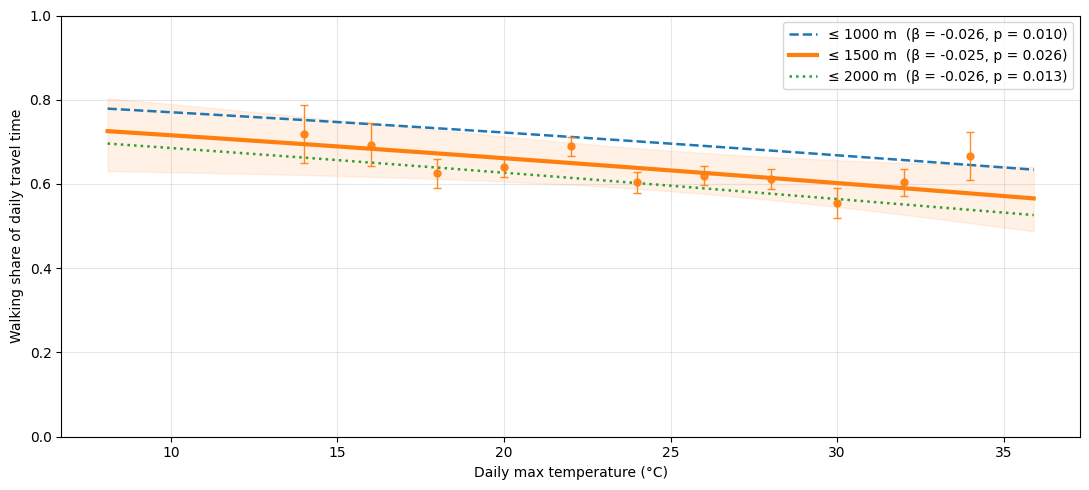

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Settings
thresholds = [1000, 1500, 2000]
main_threshold = 1500 # This corresponds roughly to the 90th percentile of walking trip distances. TODO: check if this is a common threshold for walkable trips in the literature

bin_width = 2
min_bin_count = 10
min_trips_per_day = 2

colors = {
    1000: "C0",
    1500: "C1",
    2000: "C2",
}

line_widths = {
    1000: 1.8,
    1500: 3.0,
    2000: 1.8,
}

line_styles = {
    1000: "--",
    1500: "-",
    2000: ":",
}

# -----------------------------
# Base data prep
# -----------------------------
df_plot = movements.copy()

df_plot["month"] = pd.to_datetime(df_plot["date"]).dt.month
df_plot = df_plot[df_plot["month"].isin([6, 7, 8, 9])].copy()

df_plot["start_time"] = pd.to_datetime(df_plot["start_time"], errors="coerce")
df_plot["end_time"] = pd.to_datetime(df_plot["end_time"], errors="coerce")
df_plot["duration"] = (df_plot["end_time"] - df_plot["start_time"]).dt.total_seconds()

df_plot = df_plot[df_plot["duration"].notna() & (df_plot["duration"] > 0)].copy()

person_day_max = build_person_day_max_temp_from_cache(df_plot, gh_prec=6)
df_plot = df_plot.merge(person_day_max, on=["participant_id", "date"], how="left")
df_plot = df_plot.dropna(subset=["max_temp"])

df_plot["walk_duration"] = np.where(df_plot["mean_of_transport"] == "Walking", df_plot["duration"], 0)

# shared prediction grid
temps = np.linspace(df_plot["max_temp"].min(), df_plot["max_temp"].max(), 300)
pred_df = pd.DataFrame({"max_temp": temps})

fig, ax = plt.subplots(figsize=(11, 5))

for thr in thresholds:
    # Restrict to trips below threshold
    df_thr = df_plot[df_plot["distance(m)"] <= thr].copy()

    daily_thr = (
        df_thr.groupby(["participant_id", "date"], as_index=False)
        .agg(
            max_temp=("max_temp", "max"),
            total_duration=("duration", "sum"),
            walk_duration=("walk_duration", "sum"),
            total_trips=("mean_of_transport", "count"),
        )
    )

    daily_thr = daily_thr[
        (daily_thr["total_duration"] > 0)
        # uncomment to have a minimum number of trips per day, to avoid very sparse days where the walk ratio is either 0% or 100% by construction
        # & (daily_thr["total_trips"] >= min_trips_per_day)
    ].copy()

    if len(daily_thr) < 20:
        continue

    daily_thr["walk_ratio"] = daily_thr["walk_duration"] / daily_thr["total_duration"]
    daily_thr["temp_bin_2"] = (np.floor(daily_thr["max_temp"] / bin_width) * bin_width).astype(int)

    # Fit model (genralized linear model with binomial family for proportions, clustered standard errors by participant_id)
    model = smf.glm(
        "walk_ratio ~ max_temp",
        data=daily_thr,
        family=sm.families.Binomial()
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": daily_thr["participant_id"]}
    )

    # Print beta and p-value for model with the current threshold
    print(f"Threshold: {thr} m - β: {model.params['max_temp']:.3f}, p-value: {model.pvalues['max_temp']:.3f}")
    print(model.summary())

    # Predicted curve
    pred = model.get_prediction(pred_df).summary_frame()

    label = f"≤ {thr} m  (β = {model.params['max_temp']:.3f}, p = {model.pvalues['max_temp']:.3f})"
    if thr == main_threshold:
        label = f"≤ {thr} m  (β = {model.params['max_temp']:.3f}, p = {model.pvalues['max_temp']:.3f})"

    ax.plot(
        temps,
        pred["mean"],
        color=colors[thr],
        linewidth=line_widths[thr],
        linestyle=line_styles[thr],
        label=label,
        zorder=3,
    )

    # CI band only for main threshold
    if thr == main_threshold:
        ax.fill_between(
            temps,
            pred["mean_ci_lower"],
            pred["mean_ci_upper"],
            color=colors[thr],
            alpha=0.10,
            zorder=1,
        )

        # Observed binned means + SE only for main threshold
        obs = (
            daily_thr.groupby("temp_bin_2")["walk_ratio"]
            .agg(["mean", "std", "count"])
            .reset_index()
        )
        obs = obs[obs["count"] >= min_bin_count].copy()
        obs["se"] = obs["std"] / np.sqrt(obs["count"])

        ax.errorbar(
            obs["temp_bin_2"],
            obs["mean"],
            yerr=obs["se"],
            fmt="o",
            color=colors[thr],
            ecolor=colors[thr],
            elinewidth=1,
            capsize=3,
            markersize=5,
            alpha=0.9,
            zorder=4,
        )

ax.set_xlabel("Daily max temperature (°C)")
ax.set_ylabel("Walking share of daily travel time")
#ax.set_title("Walking Share vs Temperature for Walkable Trips")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()